In [1]:
# NOTE:
#  - this NB aims to model an observed source with bm
#  - here there is an improved version of the optimiser
#  - this is the same as `demo_sources_ebands_fit_benchmrk`, but in the full eband [2.0, 50.0] keV

# NOTE: this NB TESTS the efficiency of the FLEXIBLE implementations for SOURCE MODEL and IROS

from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable, Iterable
from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np

from bloodmoon.coords import shift2pos
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

from flexible_IROS_rec_procedure import Source
from flexible_IROS_rec_procedure import iros_singleCAM
from flexible_source_model import model_shadowgram, model_sky


ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])

In [4]:
def _crop_inoptim(camera: CodedMaskCamera) -> tuple[int, int]:
    slit_fine, slit_coarse = ds.psf_extension(camera)
    crp = (
        slit_coarse + 5 * camera.upscale_f.y,
        slit_fine + 2 + camera.upscale_f.x,
    )
    return crp

PSF_CRP = _crop_inoptim(wfm)


def run(loop: Iterable) -> tuple[Source, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Source, ...],
    camera: CodedMaskCamera,
    varmap: NDArray | None = None,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    std = np.sqrt(varmap)
    res_ground = np.zeros_like(true_sky_)
    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.cts, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=PSF_CRP,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled, std),
            pos=pos,
            crp=PSF_CRP,
            ylabel='residues',
            labels=['', 'true - IROS', 'local sigma'],
            color=('Orange', 'DeepSkyBlue', 'm'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [9]:
# NOTE: TESTING DOUBLE FIT COORDS + CTS independently
# ALSO: optimiser logic in IROS works (almeno questo, ç#@+]#*)


from bloodmoon.coords import pos2shift

from flexible_IROS_rec_procedure import OptResult
from flexible_IROS_rec_procedure import solver

def config_optimiser(
    camera: CodedMaskCamera,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    verbose: bool = False,
    camera_coding_power: float = 0.85,
) -> Callable[[NDArray, tuple[int, int]], OptResult]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def process_skyimg(
        sky: NDArray,
        pos: tuple[int, int],
    ) -> NDArray:
        """
        Processes the sky image for optimisation.
        """
        # here we crop the source PSF slit plus an offset to account for
        # shifts and to accomodate the `curve_fit` optimisation:
        #   - along y (coarse dir) we insert an offset of `5 * upscaling`, which
        #     is ~ 1/6 of the upsampled PSF slit dimension;
        #   - along x (fine dir) we insert an offset of `2 + upscaling`, to
        #     avoid the bkg contributes from the surrounding pixels;
        # NOTE: if the offset is smaller than at least the shifts bounds in
        # `optimize()`, the optimisation procedure may fail for some sources
        psf_slit_px_y, psf_slit_px_x = (
            int(camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay),
            int(camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax),
        )
        offset_y, offset_x = (
            5 * camera.upscale_f.y, 2 + camera.upscale_f.x,
        )

        i, j = pos
        crop_y, crop_x = (
            psf_slit_px_y + offset_y, psf_slit_px_x + offset_x,
        )
        slice_y, slice_x = (
            slice(i - crop_y, i + crop_y + 1), slice(j - crop_x, j + crop_x + 1),
        )
        cropped = sky[slice_y, slice_x]
        return cropped.flatten()

    def _model_coords(arg_sky: tuple[int, int]) -> Callable[[NDArray, float, float], NDArray]:
        """
        Initialises the source model for coords optimisation.
        """
        def f(x: NDArray, shift_x: float, shift_y: float) -> NDArray:
            """Models the source sky image."""
            modeled = model_sky(camera, shift_x, shift_y, 1e6, vignetting, psfy)
            modeled /= modeled.max()
            return process_skyimg(modeled, arg_sky)
        
        return f
    
    def _model_cts(
        arg_sky: tuple[int, int],
        opt_coord_x: float,
        opt_coord_y: float,
    ) -> Callable[[NDArray, float], NDArray]:
        """
        Initialises the source model for counts optimisation.
        """
        def f(x: NDArray, cts: float) -> NDArray:
            """Models the source sky image."""
            modeled = model_sky(camera, opt_coord_x, opt_coord_y, cts, vignetting, psfy)
            return process_skyimg(modeled, arg_sky)
        
        return f

    def optimiser(
        sky: NDArray,
        arg_sky: tuple[int, int],
    ) -> OptResult:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        lst_kwargs = {
            'method': 'trf',
            'jac': '3-point',
            'ftol': 1e-8,
            'xtol': 1e-8,
            'x_scale': 'jac',
            'loss': 'linear',
        }
        sky_peak: float = sky[*arg_sky]

        if fit_weights is None:
            weights = np.ones_like
        elif callable(fit_weights):
            weights = fit_weights
        else:
            weights = lambda x: fit_weights

        # --- perform 1st optimisation: source coords
        print('### Coords Optimisation...')
        model_coords_func = _model_coords(arg_sky)
        sky_ydata = process_skyimg(sky, arg_sky)
        w = weights(sky_ydata)
        sky_ydata /= sky_peak

        sx_start, sy_start = pos2shift(camera, *arg_sky)
        start_params_vals = np.array([sx_start, sy_start])
        
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        bounds = [
            (
                max(sx_start - camera.upscale_f.x * px_dim_x, camera.bins_sky.x[0]),
                max(sy_start - camera.upscale_f.y * px_dim_y, camera.bins_sky.y[0]),
            ),
            (
                min(sx_start + camera.upscale_f.x * px_dim_x, camera.bins_sky.x[-1]),
                min(sy_start + camera.upscale_f.y * px_dim_y, camera.bins_sky.y[-1]),
            ),
        ]
        slvr_kwargs = {
            'p0': start_params_vals,
            'sigma': w,
            'bounds': bounds,
            **lst_kwargs,
        }
        crds_result = solver(
            func=model_coords_func,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            verbose=verbose,
            **slvr_kwargs,
        )
        sx, sy = map(float, crds_result.params)
        
        # --- perform 2nd optimisation: source counts
        print('### Counts Optimisation...')
        model_cts_func = _model_cts(arg_sky, sx, sy)
        sky_ydata = process_skyimg(sky, arg_sky)
        w = weights(sky_ydata)

        cts_start = sky_peak / camera_coding_power
        start_params_vals = np.array([cts_start])

        bounds = [
            [0.95 * sky_peak], [1.25 * sky_peak],
        ]
        slvr_kwargs = {
            'p0': start_params_vals,
            'sigma': w,
            'bounds': bounds,
            **lst_kwargs,
        }
        cts_result = solver(
            func=model_cts_func,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            verbose=verbose,
            **slvr_kwargs,
        )
        cts = float(cts_result.params[0])

        # --- handle optimised params
        out_params = np.array([sx, sy, cts])
        out_errs = np.concatenate([crds_result.covar, cts_result.covar])
        result = OptResult(out_params, out_errs)

        return result
    
    return optimiser

In [10]:
def comp_fit_weights(obs: NDArray) -> NDArray:
    """Computes the weights for the loss metric in the optimisation procedure."""
    return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))


max_iterations: int = 10
snr_threshold: float = 5.0
fit_weights: NDArray | Callable | None = comp_fit_weights

detector: NDArray = count(wfm, sdlA.DLdata)[0]

iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    snr_threshold=5.0,
    vignetting=VIGNETTING,
    psfy=PSFY,
    optimiser=config_optimiser(wfm, VIGNETTING, PSFY, fit_weights, True)
)
candidates: tuple[Source, ...] = run(iros_loop)

# Running IROS loop...


0it [00:00, ?it/s]

### Coords Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: -108.3500000
      - OPTIM.: -108.4131696 +/- 0.0000209
      - GAIN.: -0.058 %
  * p[1]:
      - START.: 62.5000000
      - OPTIM.: 62.6646251 +/- 0.0009839
      - GAIN.: 0.263 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality

### Counts Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 1076651.5309254
      - OPTIM.: 909115.1771966 +/- 88.0257205
      - GAIN.: -15.561 %

## Fit Report:
  - func calls (also # of iters): 8
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



1it [00:18, 18.23s/it]

### Coords Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 21.9500000
      - OPTIM.: 21.9454196 +/- 0.0001012
      - GAIN.: -0.021 %
  * p[1]:
      - START.: 64.0000000
      - OPTIM.: 63.5911792 +/- 0.0104167
      - GAIN.: -0.639 %

## Fit Report:
  - func calls (also # of iters): 12
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values

### Counts Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 312566.0454123
      - OPTIM.: 267339.9804192 +/- 217.7282008
      - GAIN.: -14.469 %

## Fit Report:
  - func calls (also # of iters): 8
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



...

### Coords Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 55.8000000
      - OPTIM.: 55.8133585 +/- 0.0004273
      - GAIN.: 0.024 %
  * p[1]:
      - START.: 22.0000000
      - OPTIM.: 21.8031248 +/- 0.0190523
      - GAIN.: -0.895 %

## Fit Report:
  - func calls (also # of iters): 19
  - procedure msg: `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values

### Counts Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 104049.4739085
      - OPTIM.: 93428.4327469 +/- 183.8457696
      - GAIN.: -10.208 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



9it [03:01, 19.98s/it]

### Coords Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: -120.1000000
      - OPTIM.: -120.1492921 +/- 0.0003362
      - GAIN.: -0.041 %
  * p[1]:
      - START.: 9.0000000
      - OPTIM.: 8.8107627 +/- 0.0175082
      - GAIN.: -2.103 %

## Fit Report:
  - func calls (also # of iters): 22
  - procedure msg: `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values

### Counts Optimisation...
## Optimisation Results:
  * p[0]:
      - START.: 96262.7974006
      - OPTIM.: 83275.6101454 +/- 157.8338313
      - GAIN.: -13.491 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



10it [03:27, 20.73s/it]

# End IROS loop...



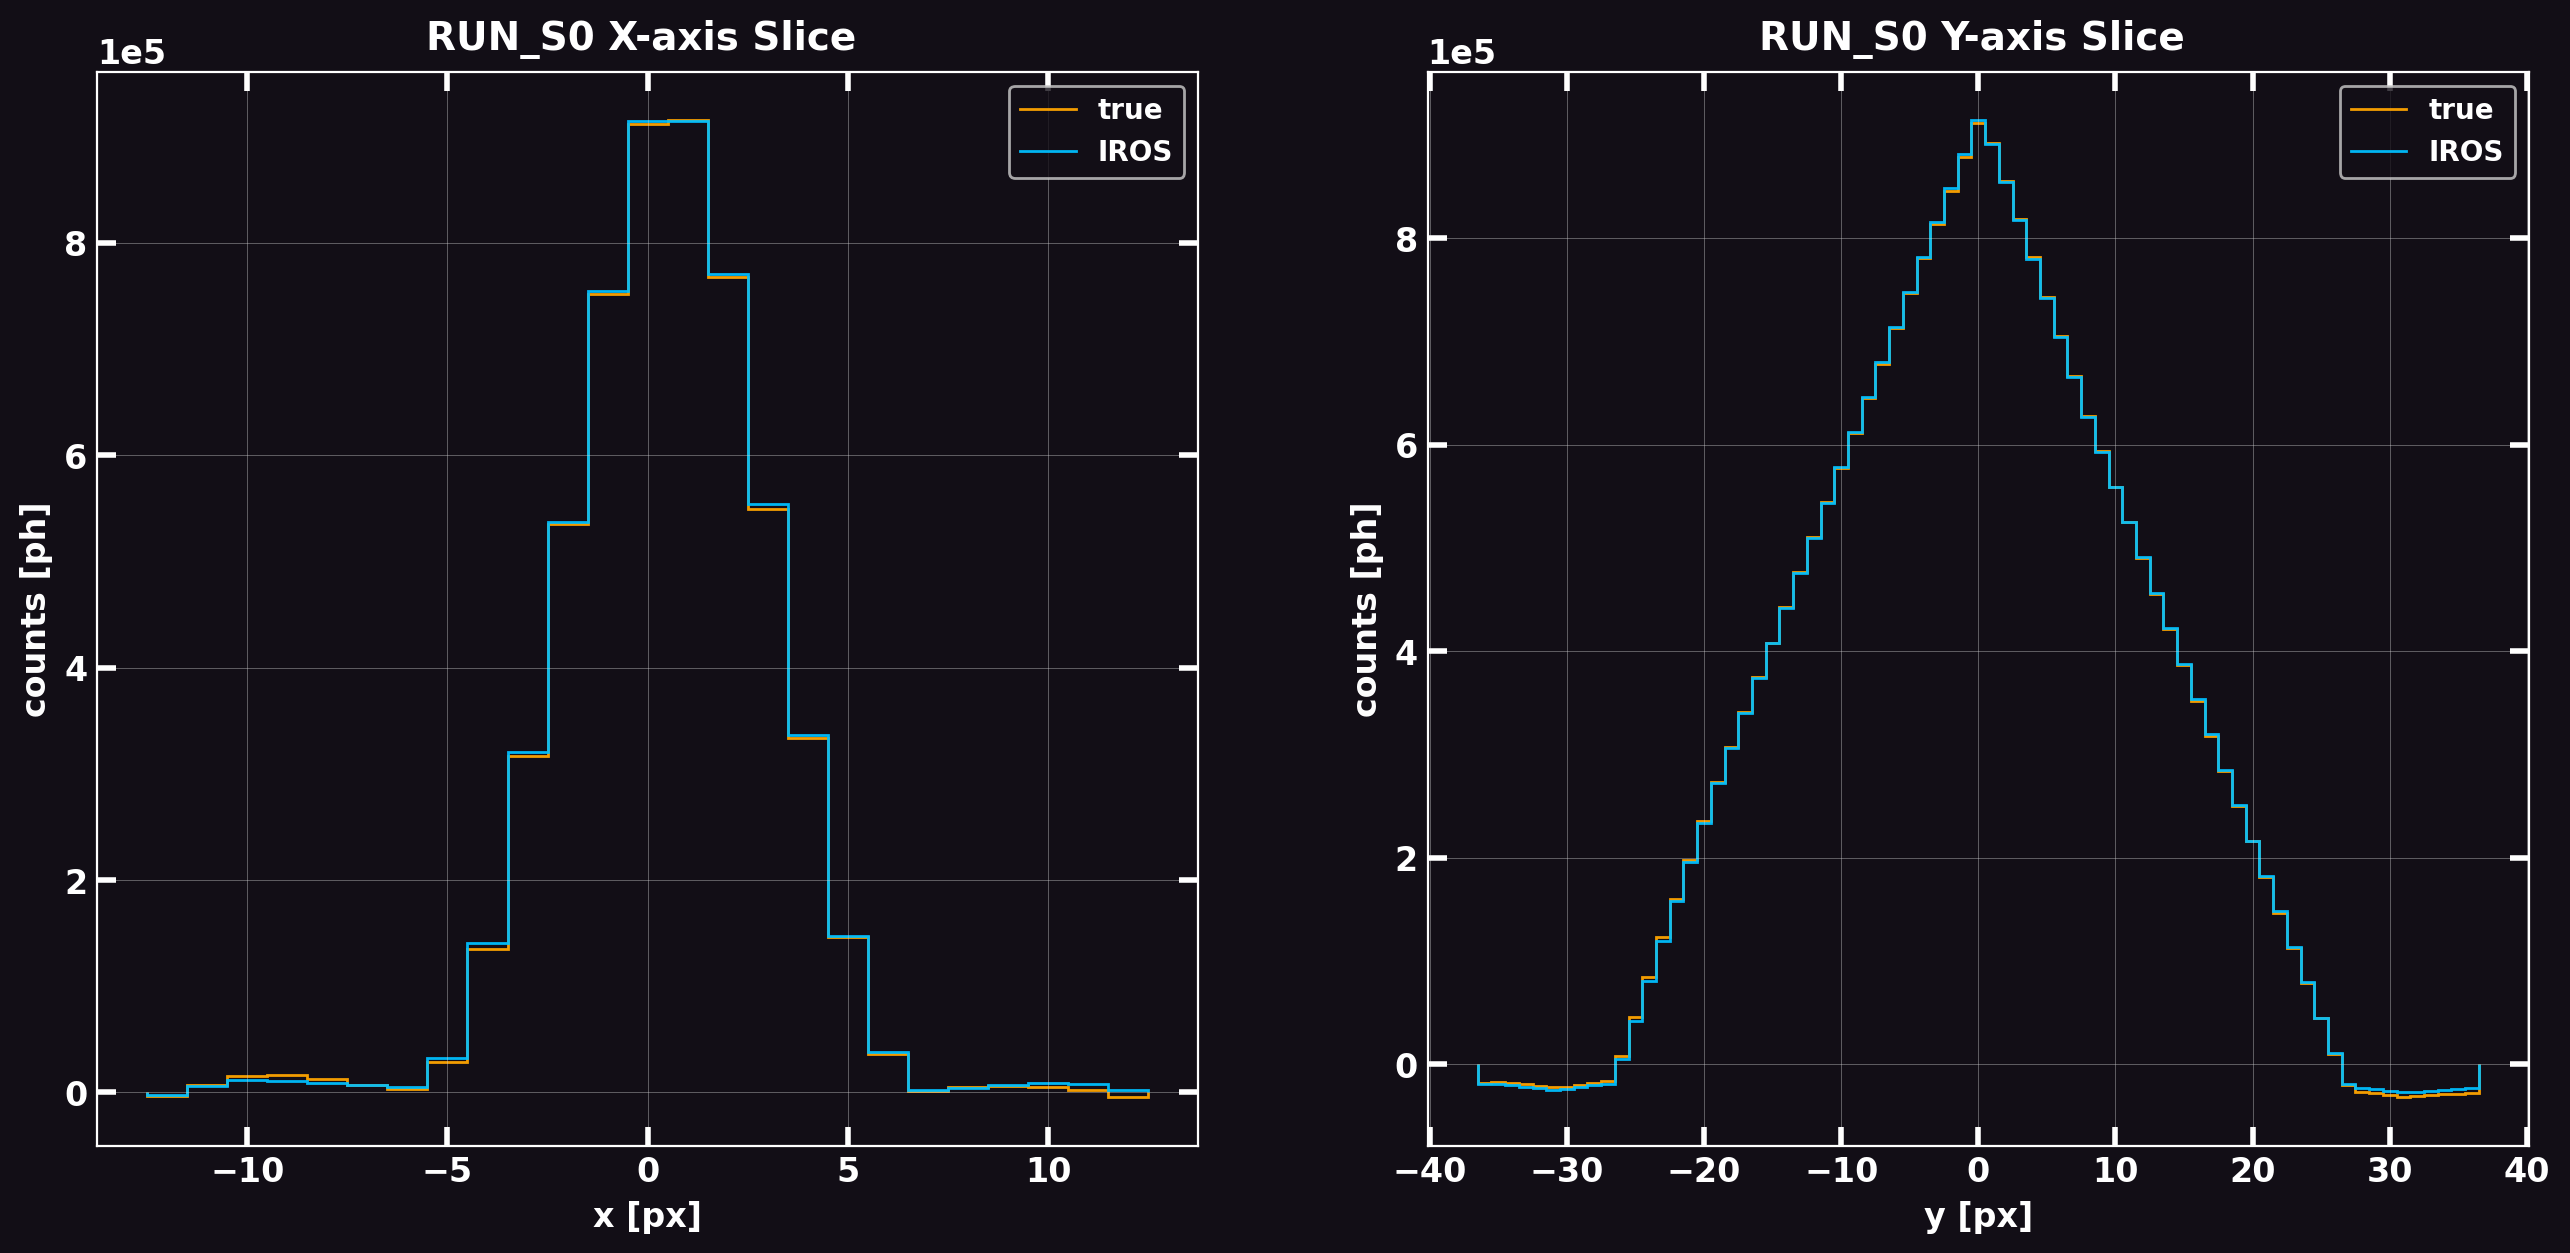

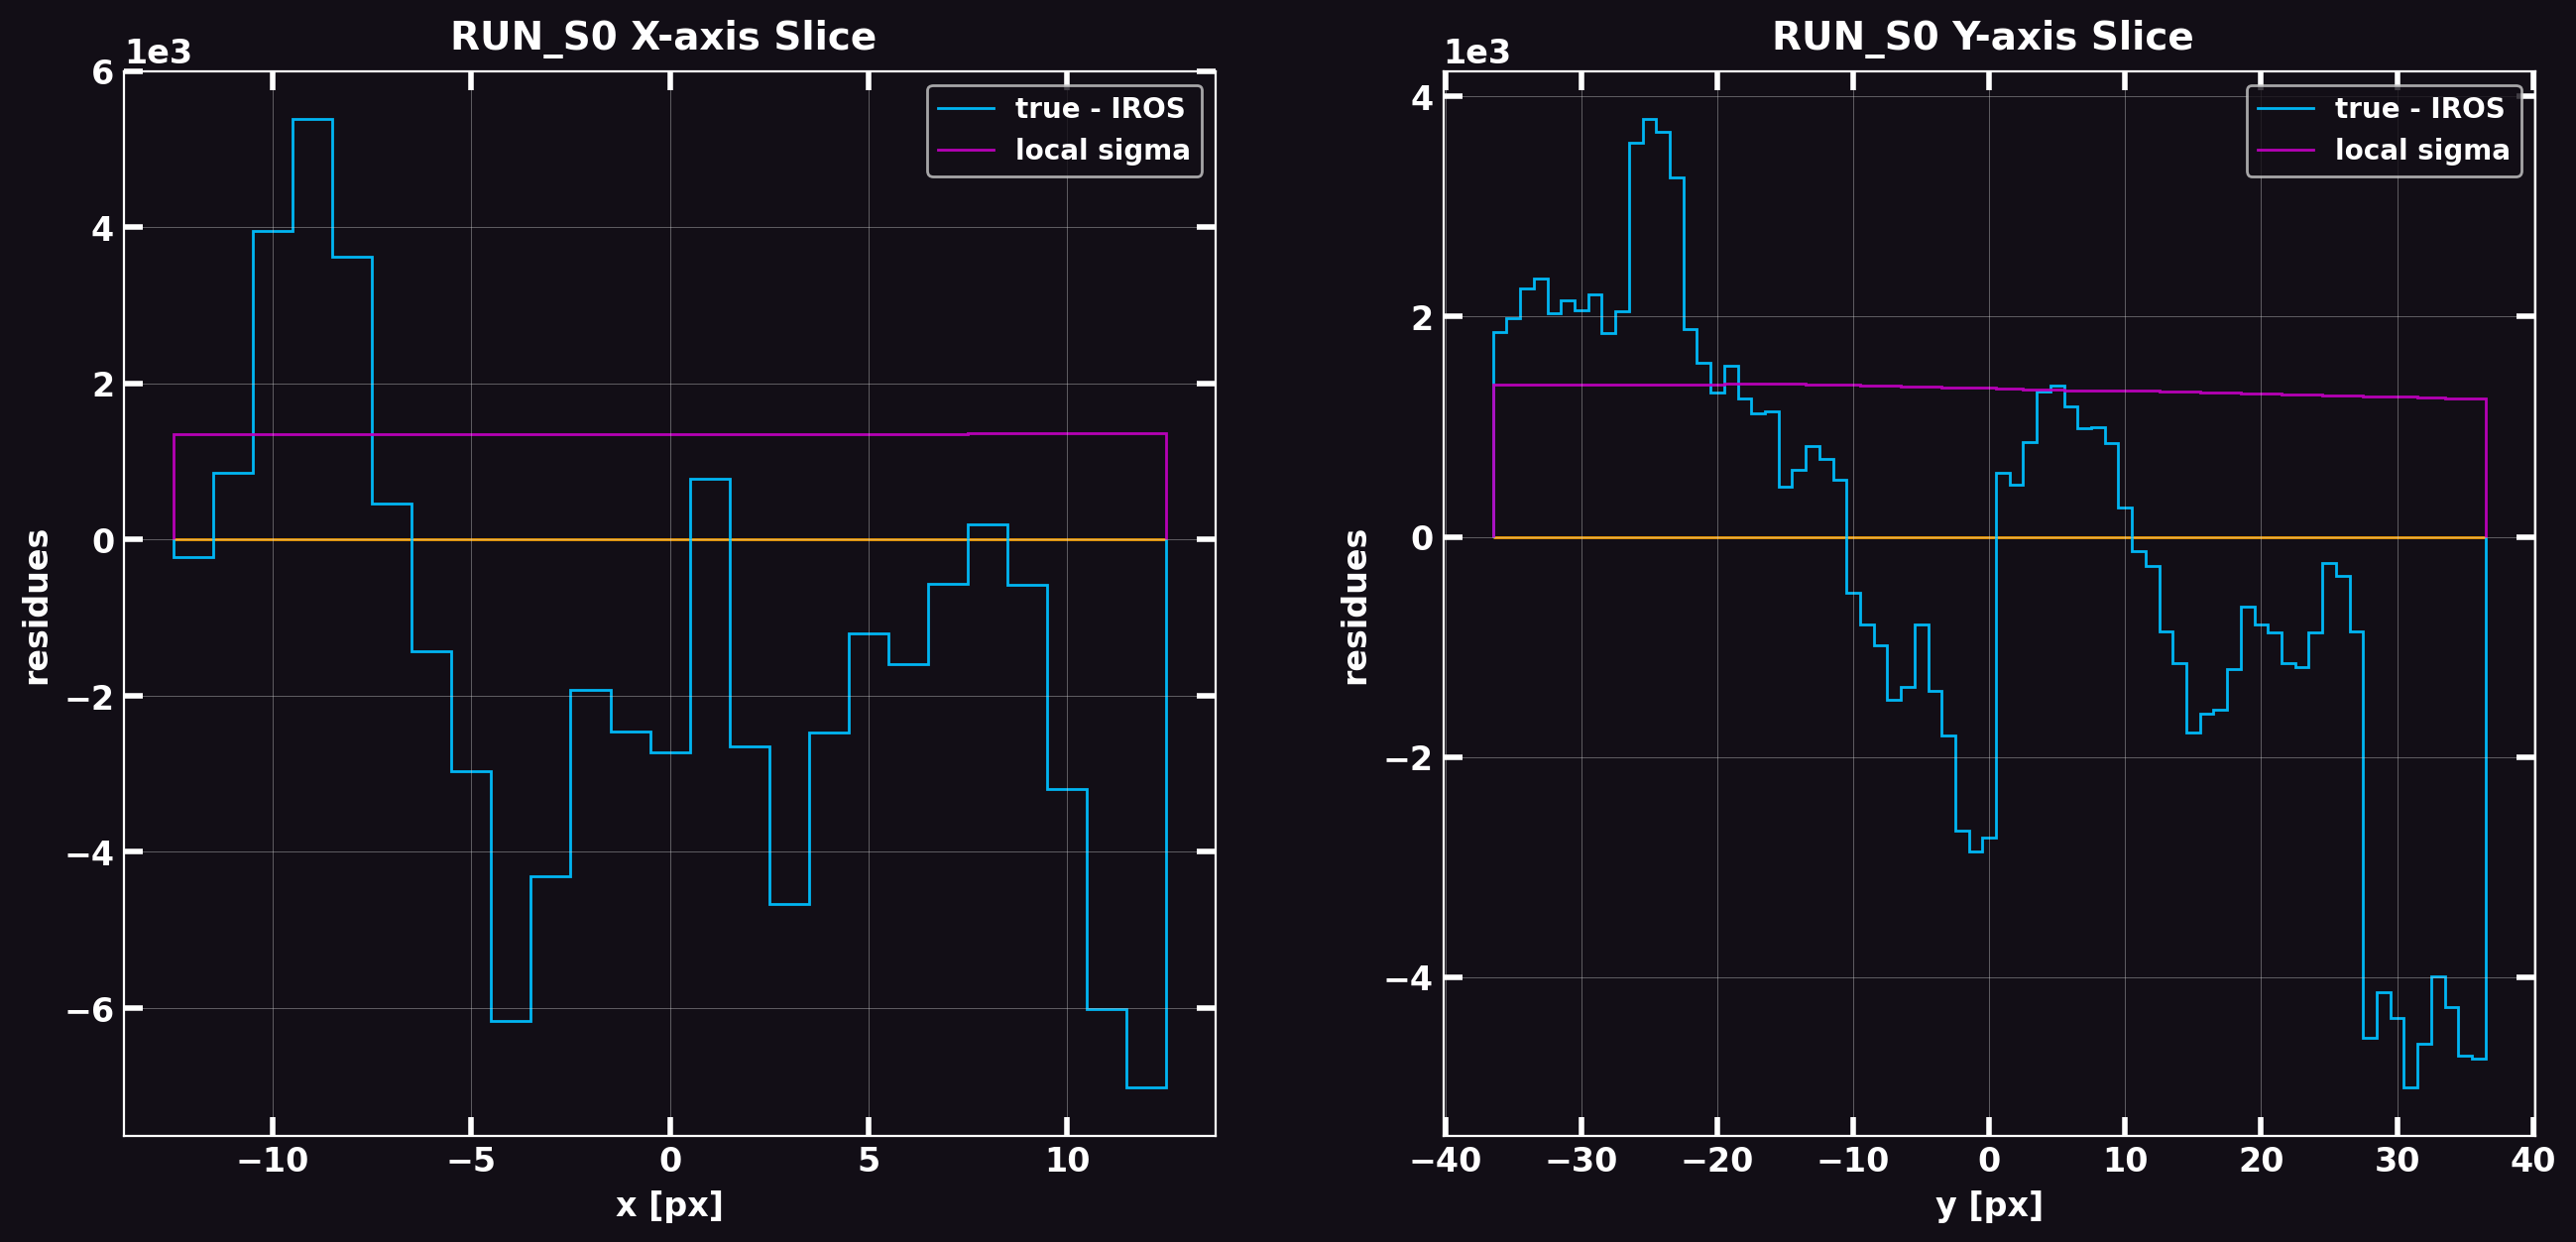

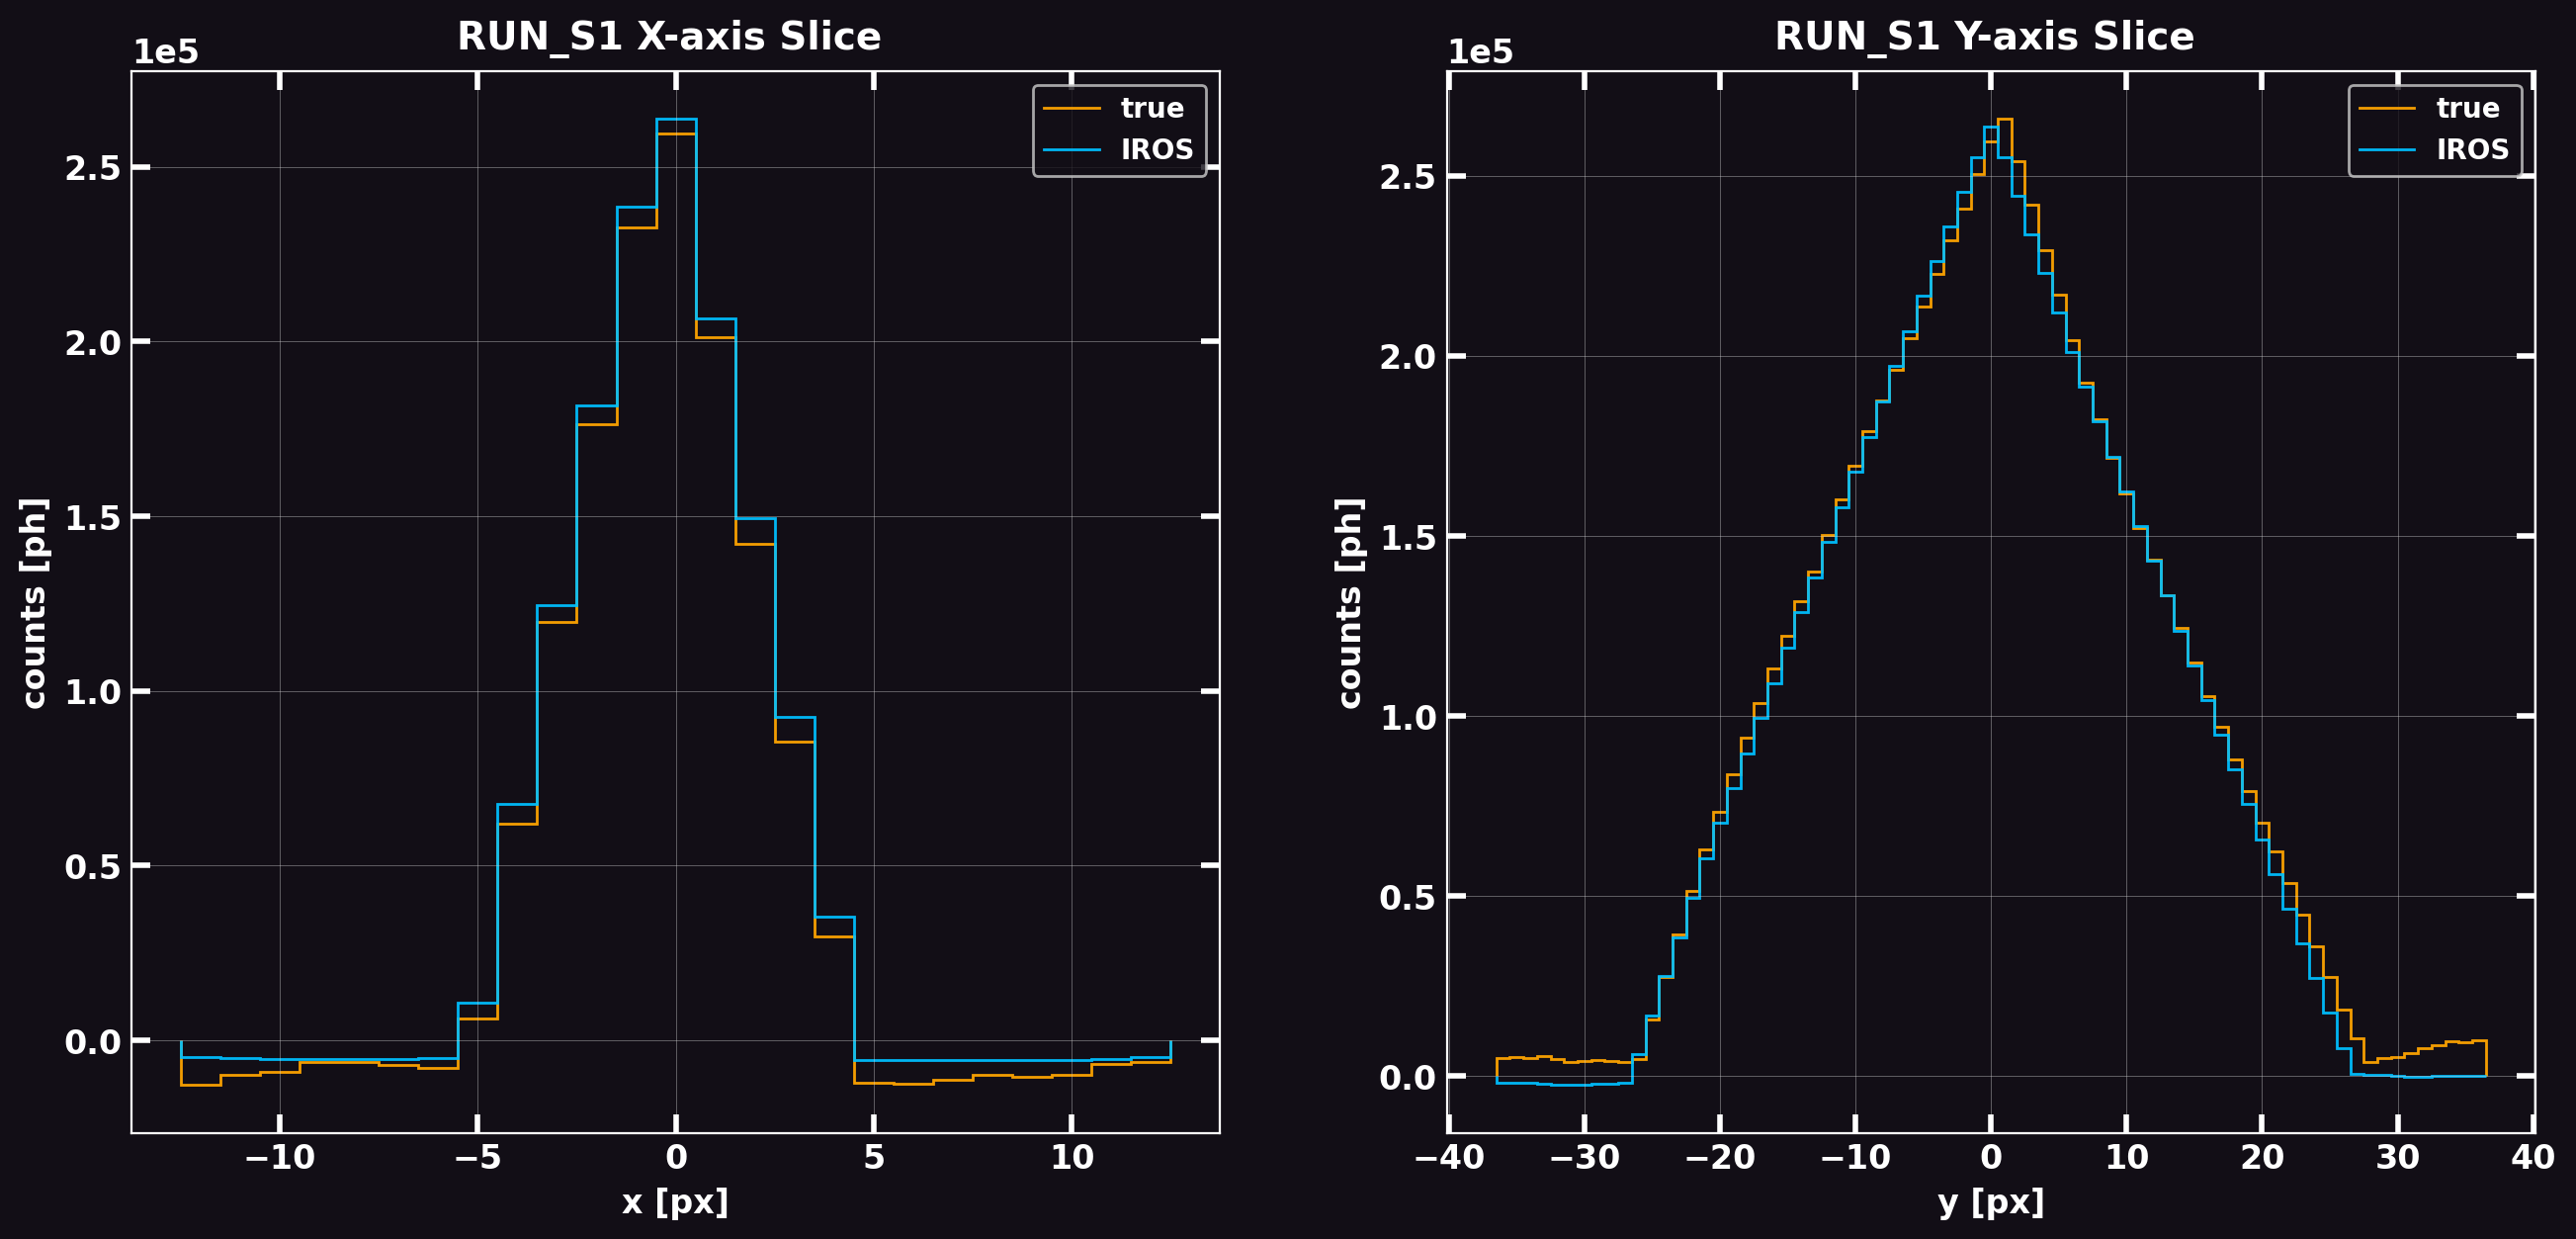

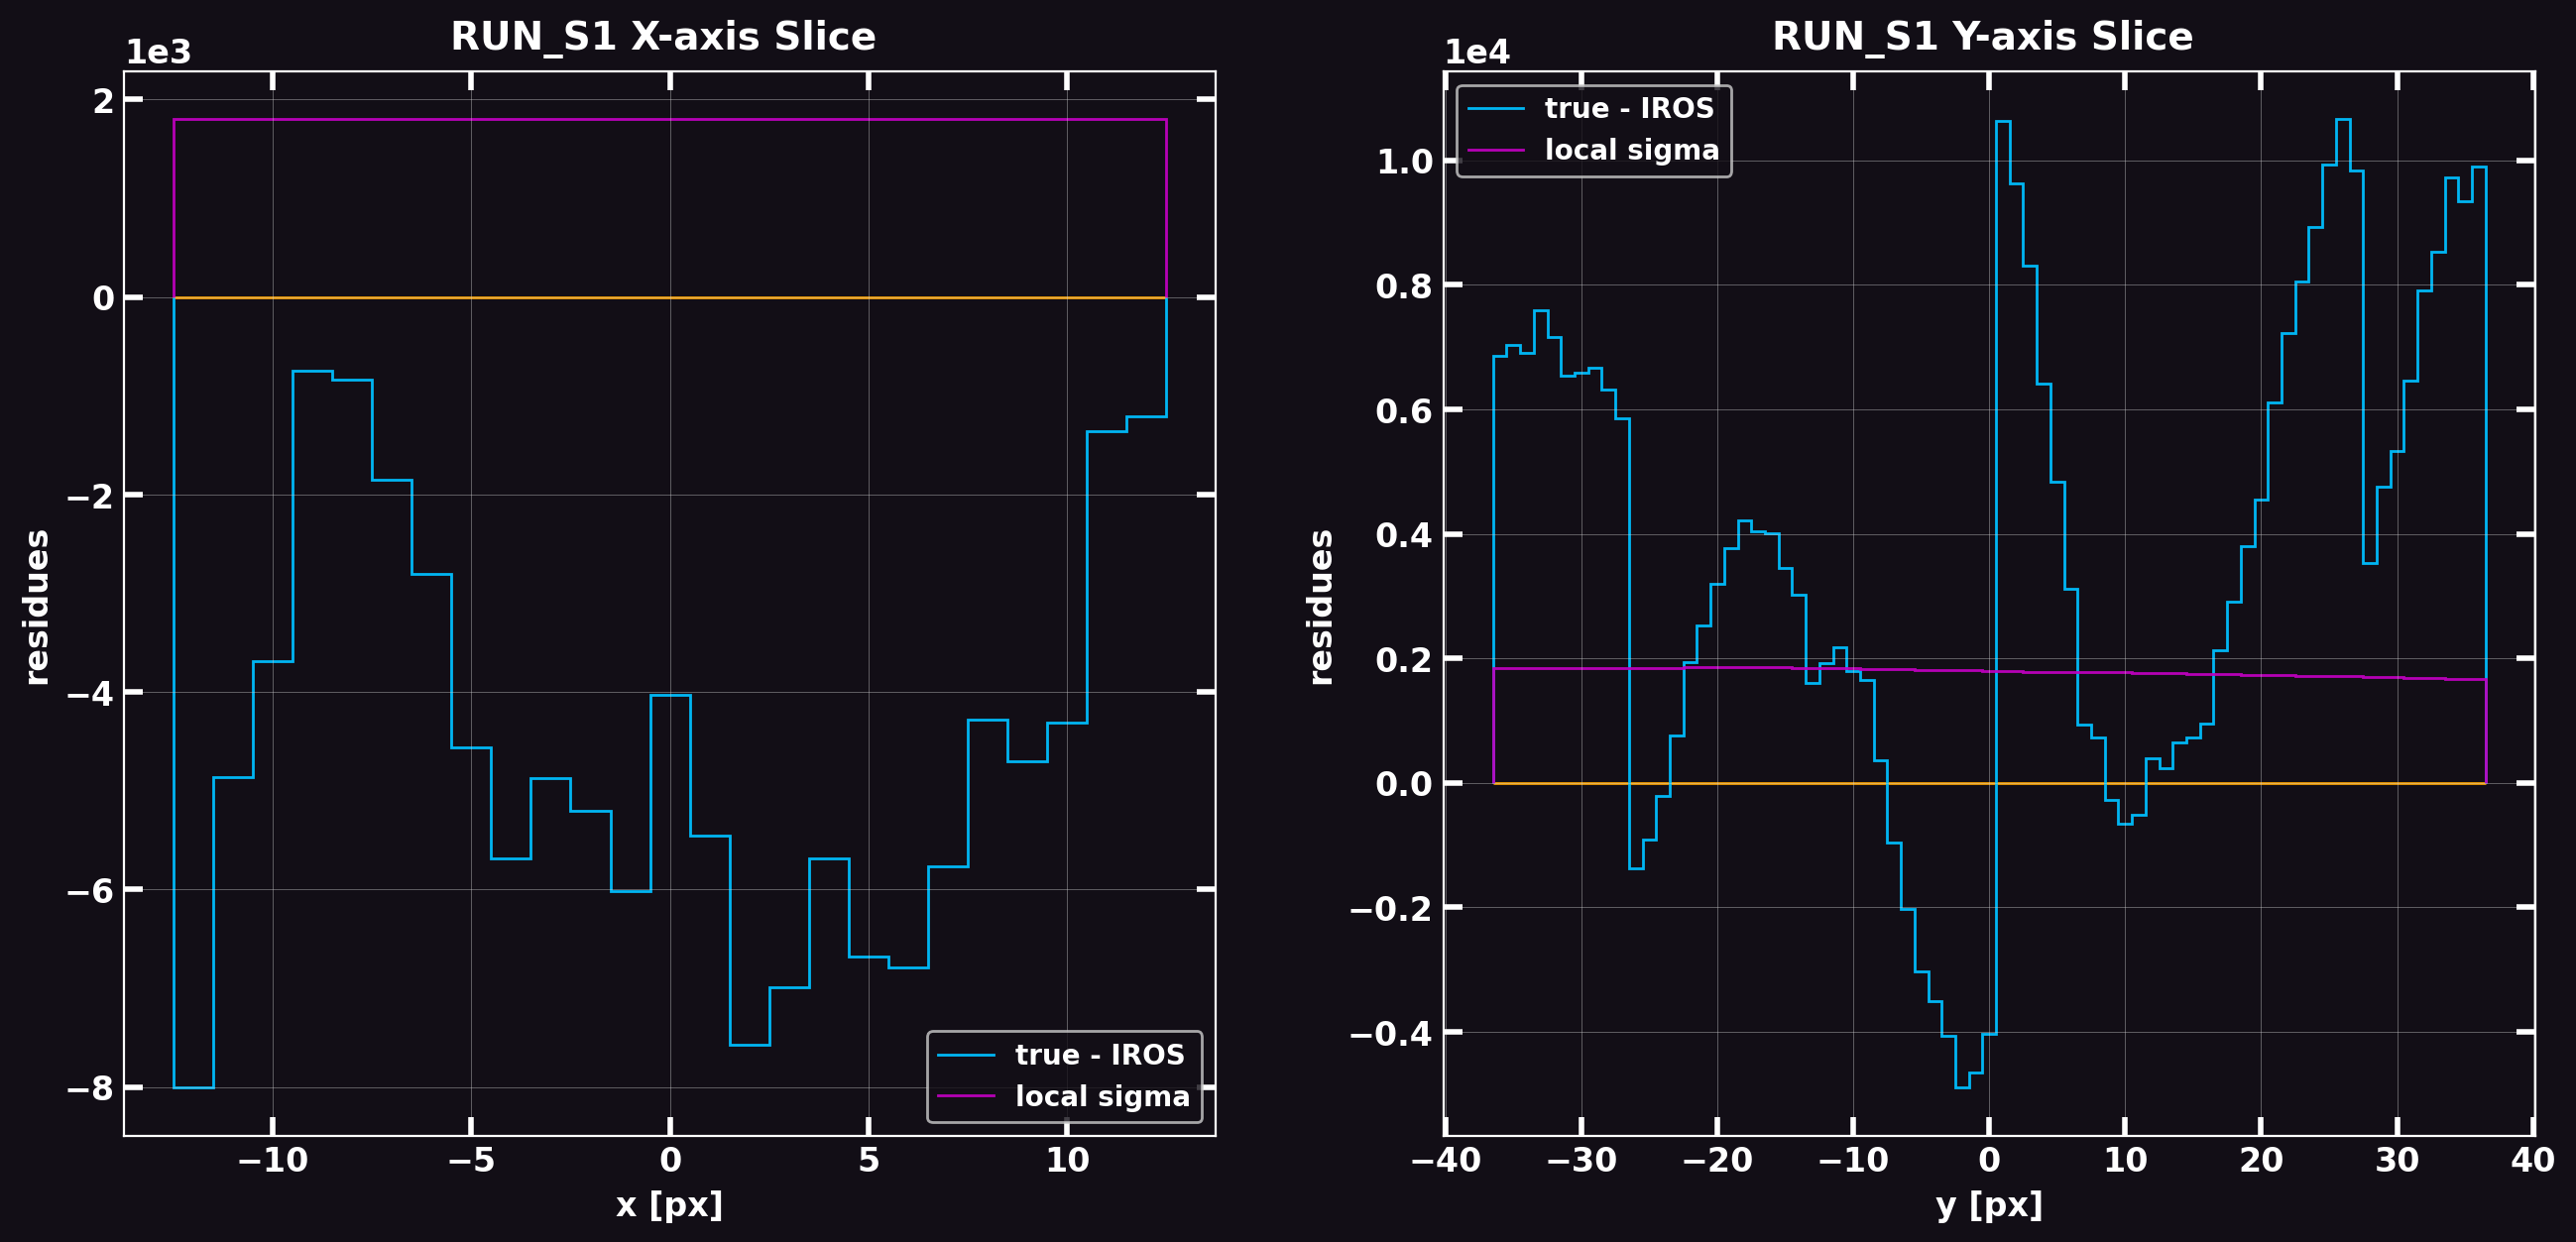

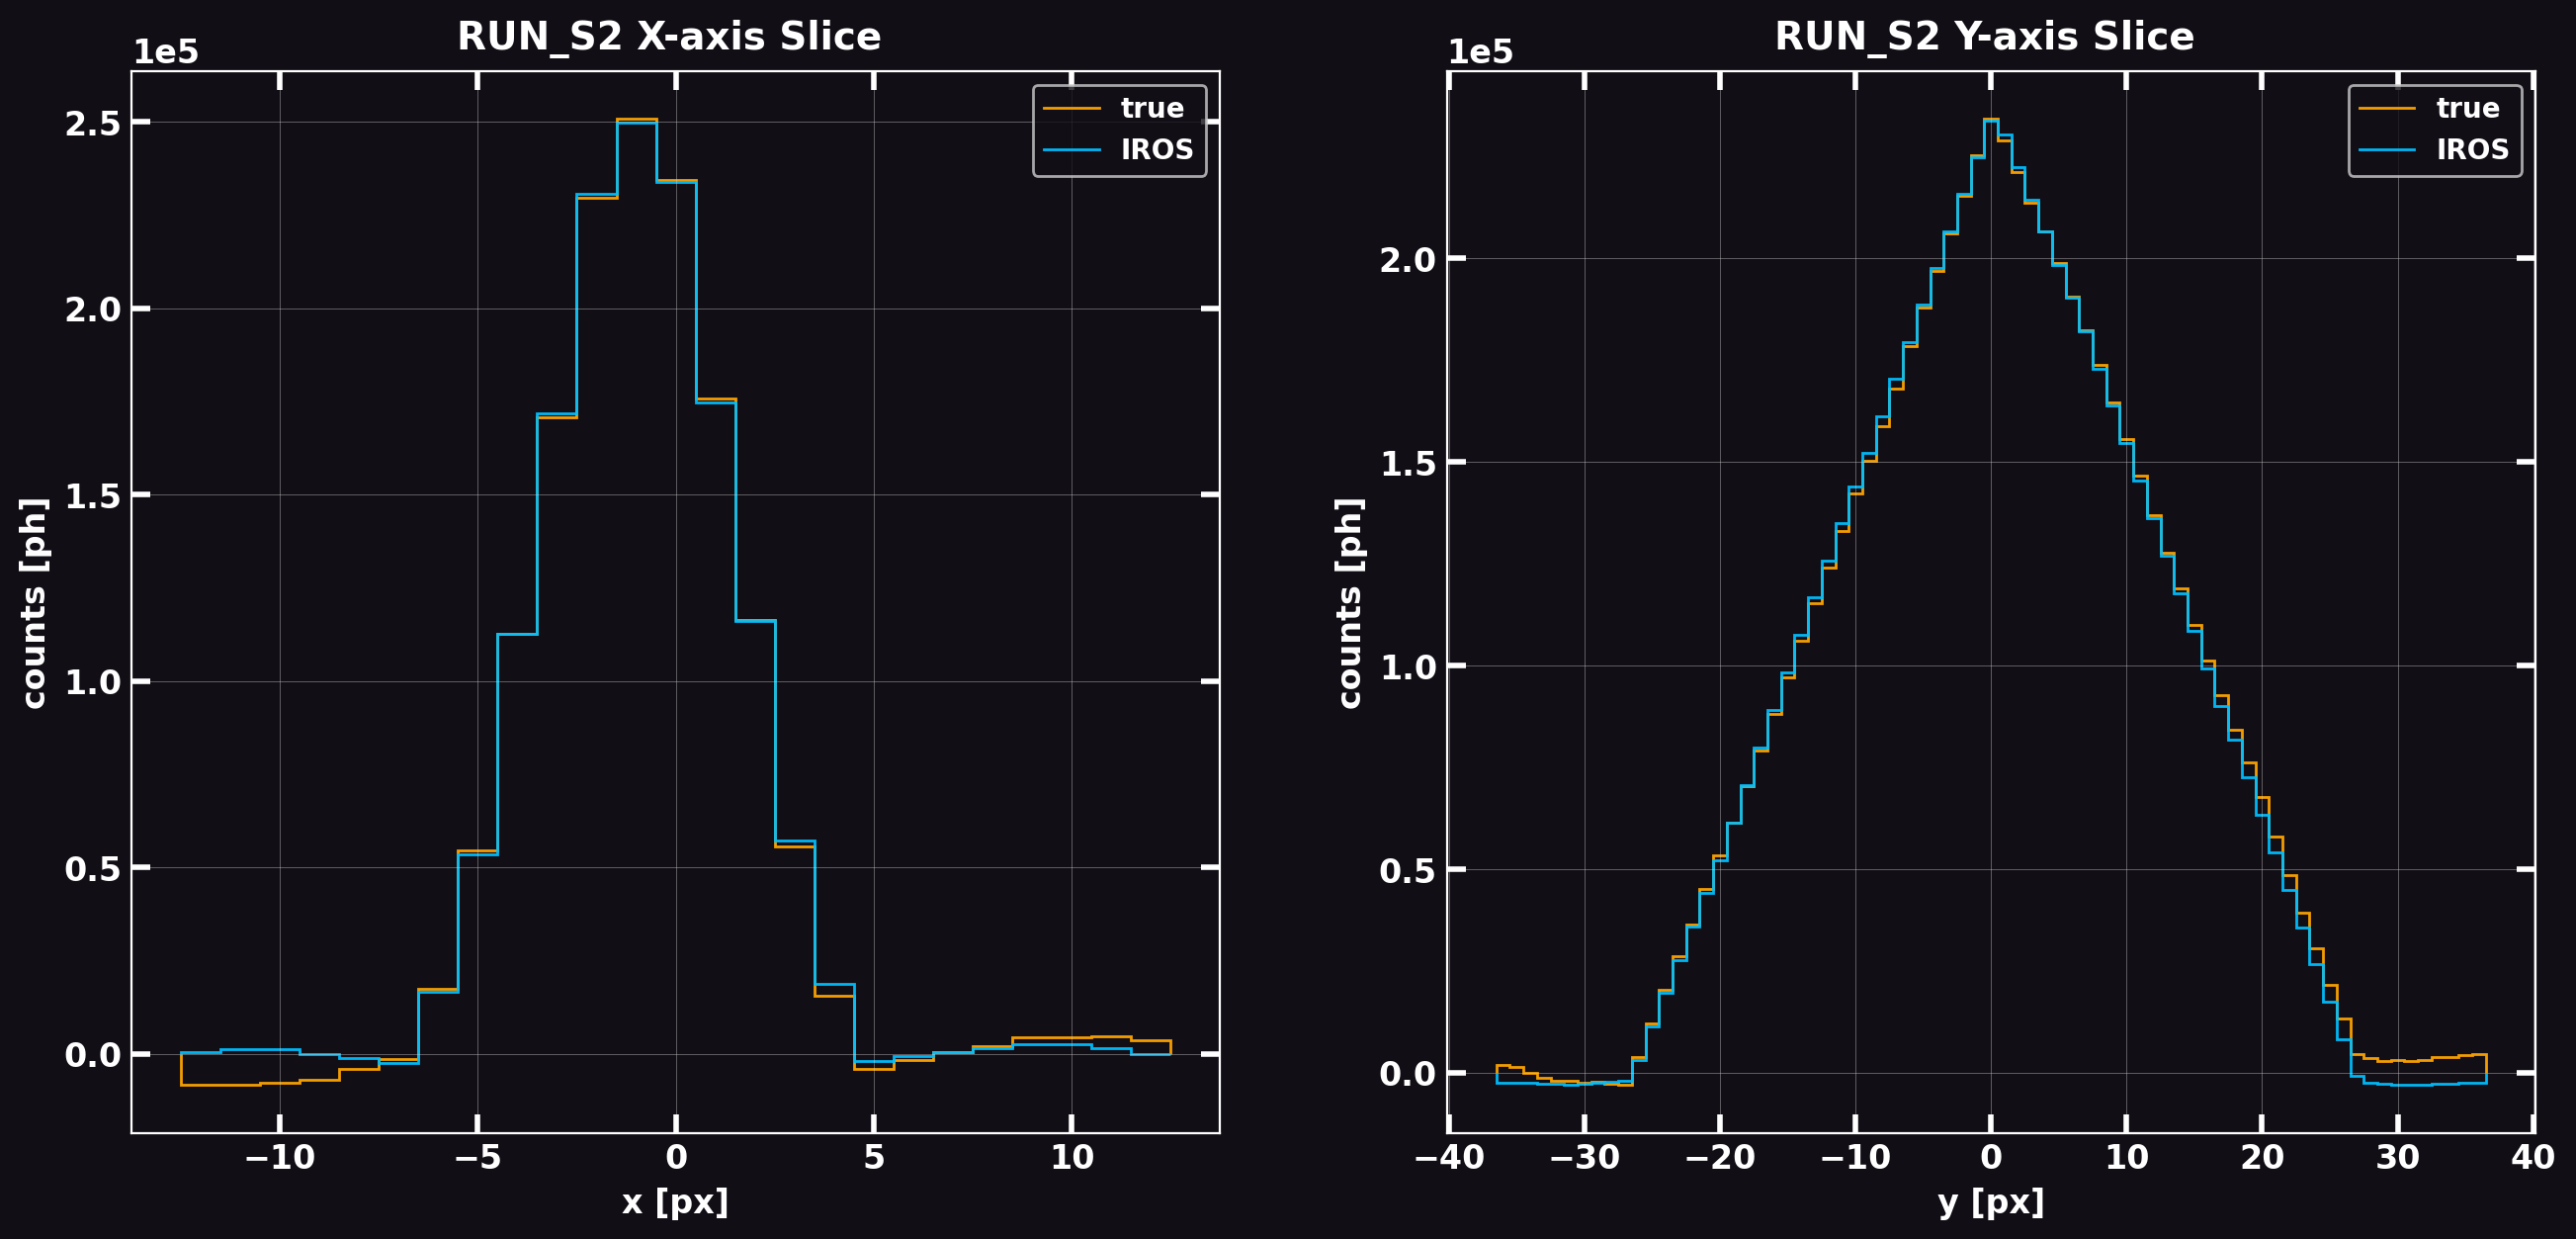

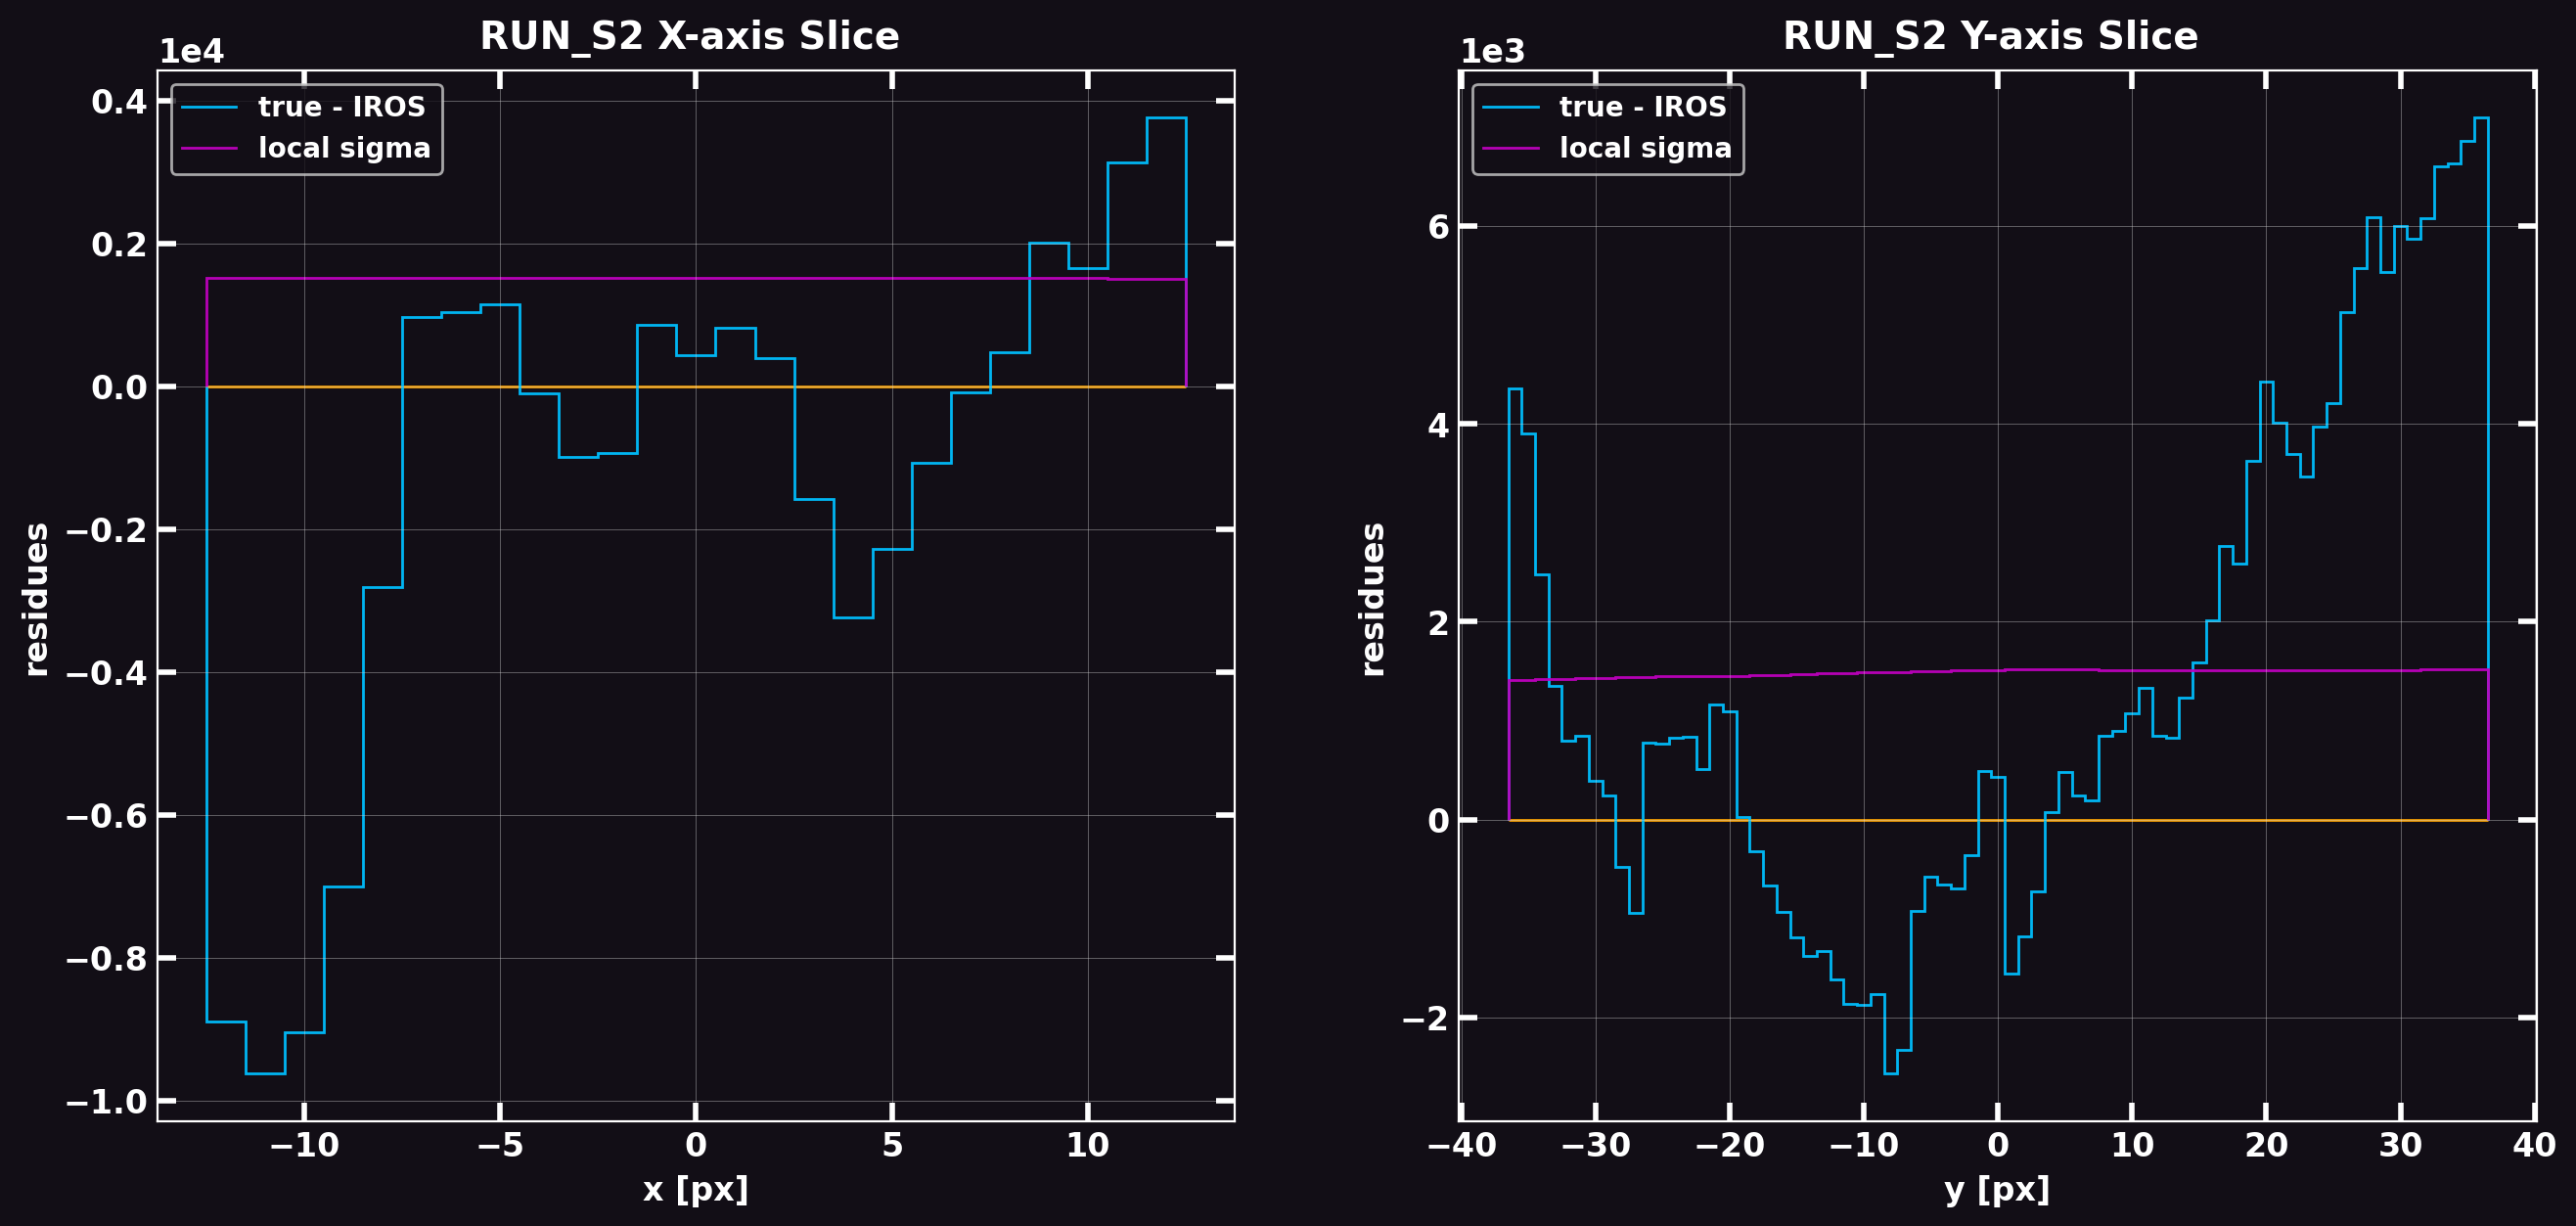

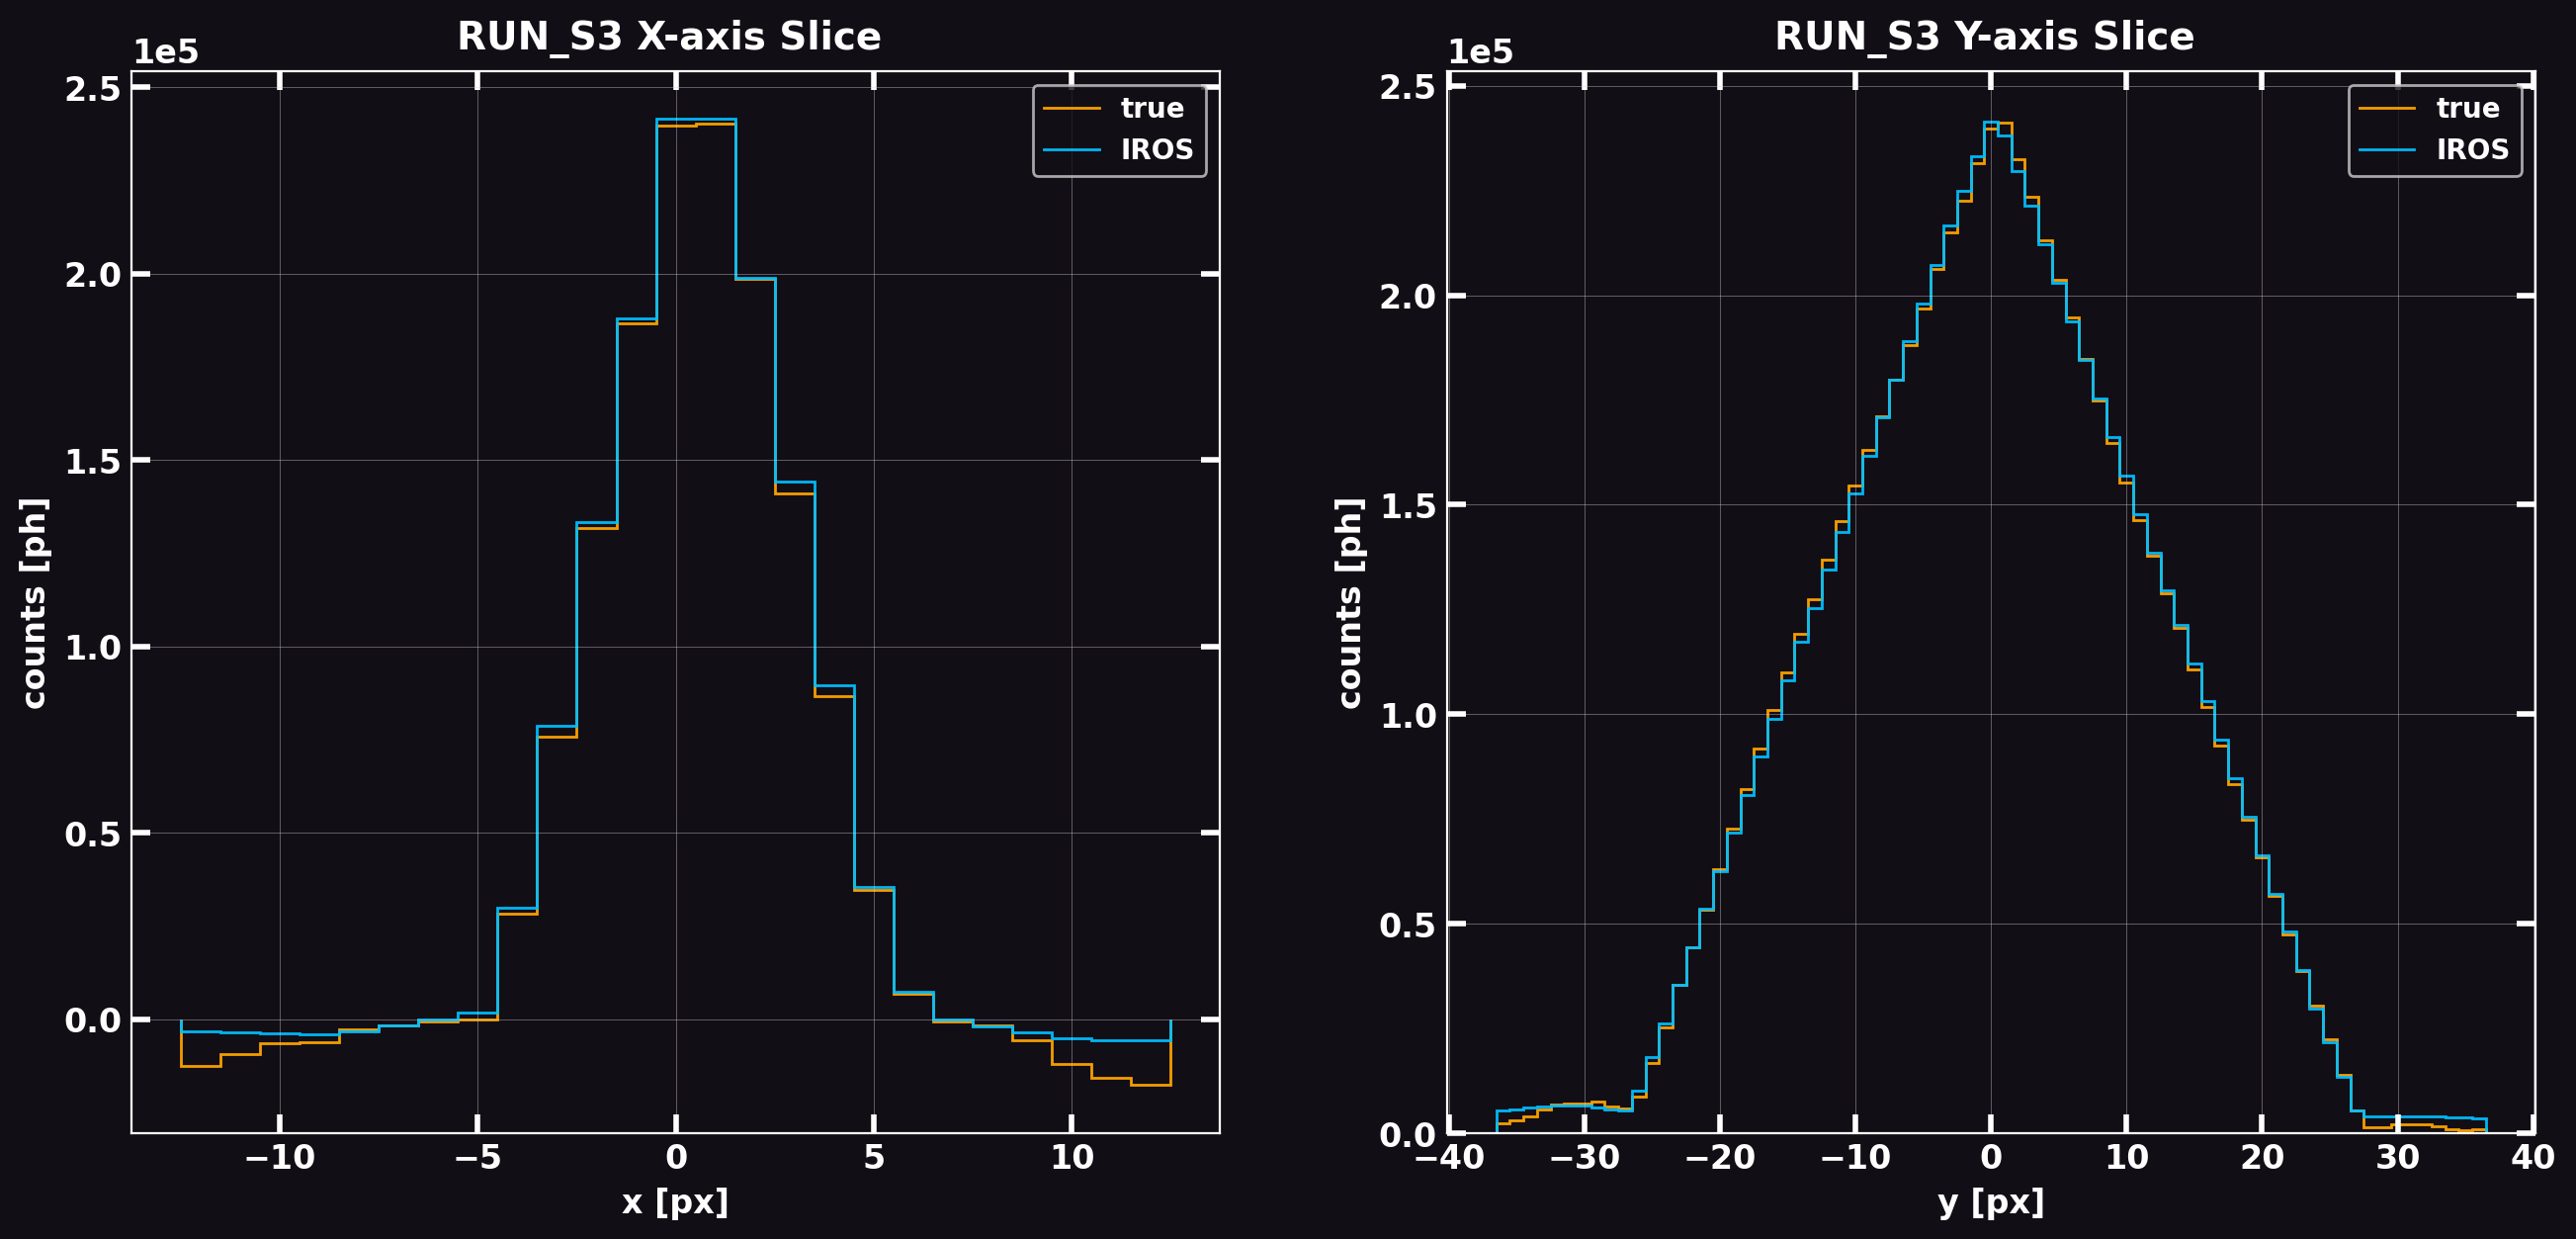

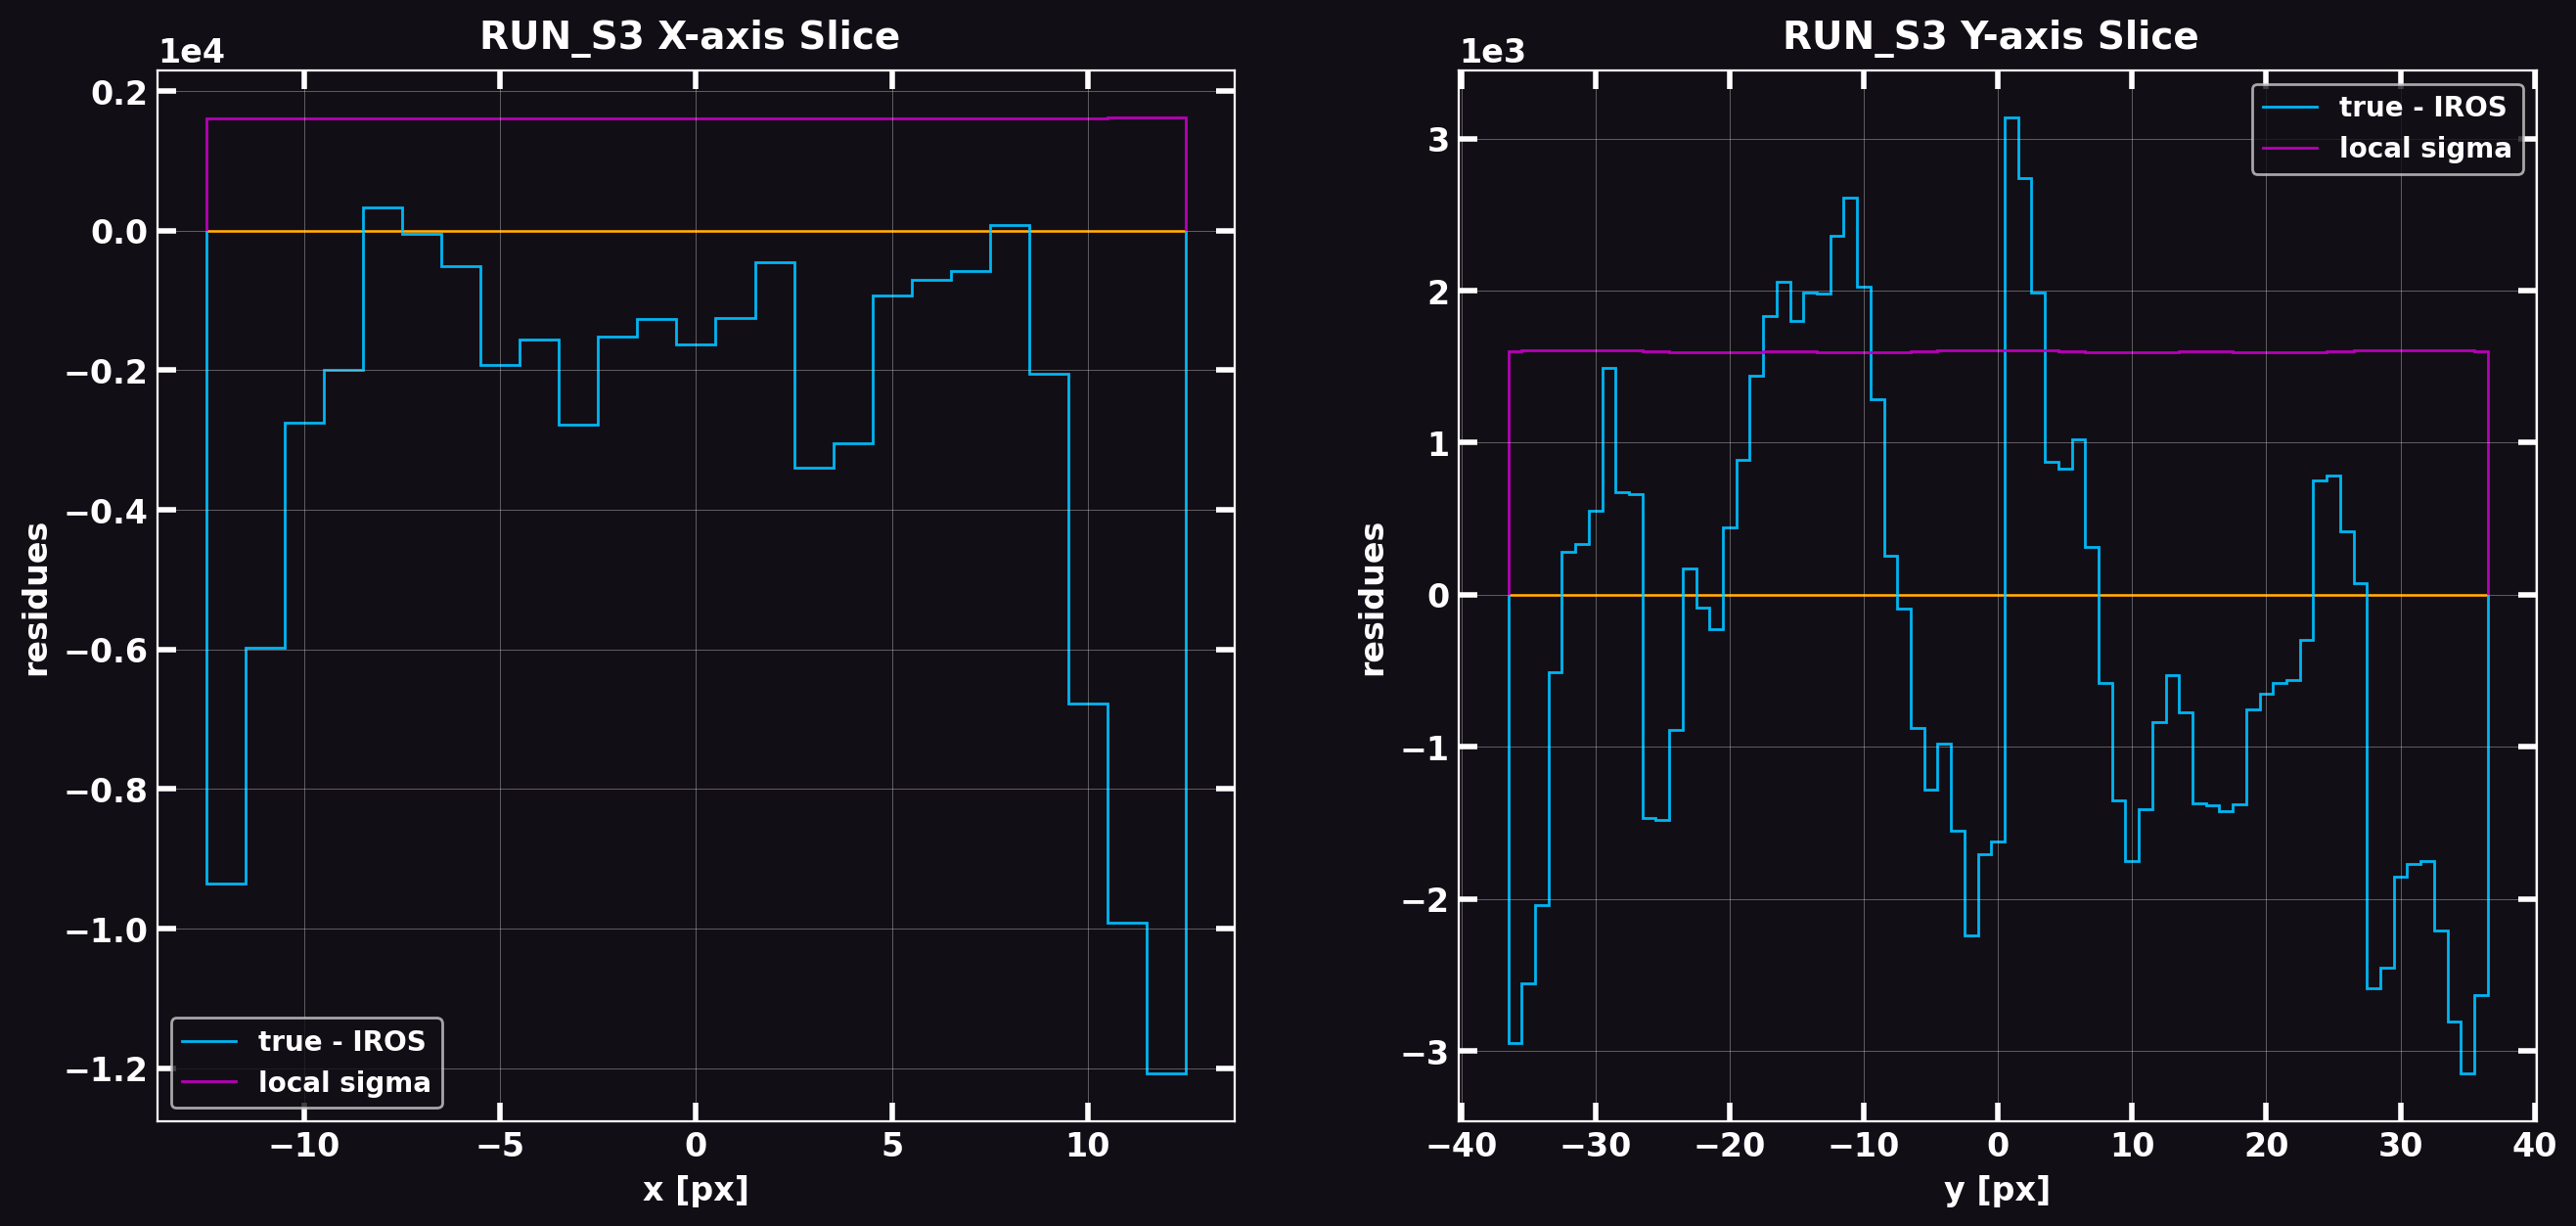

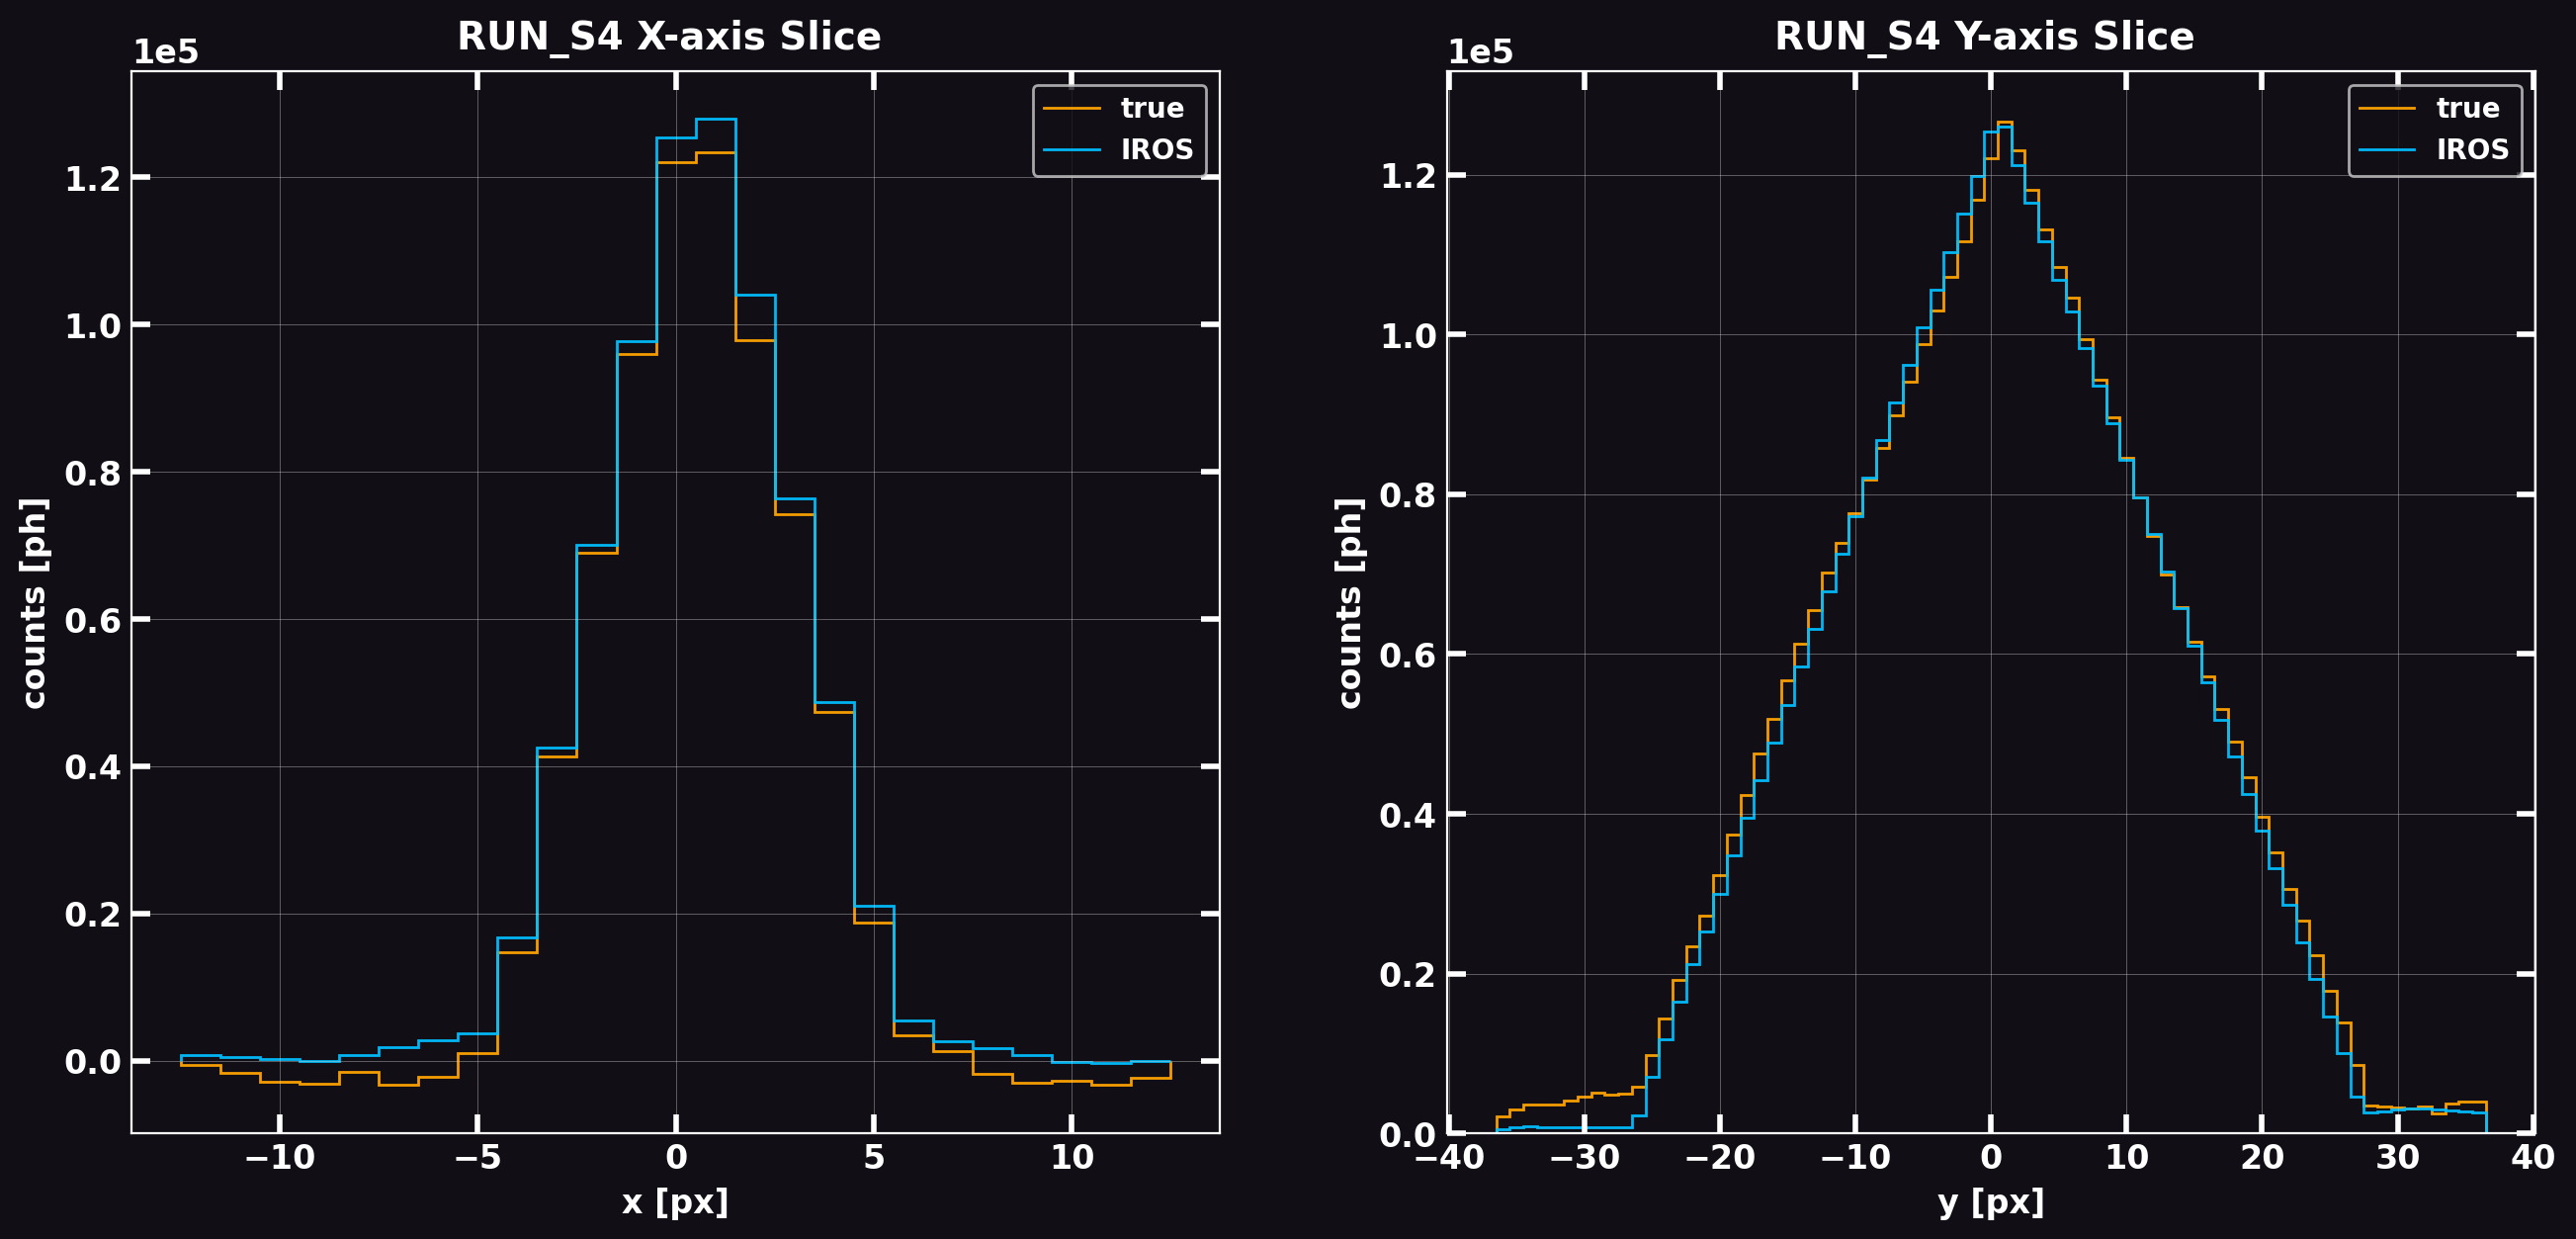

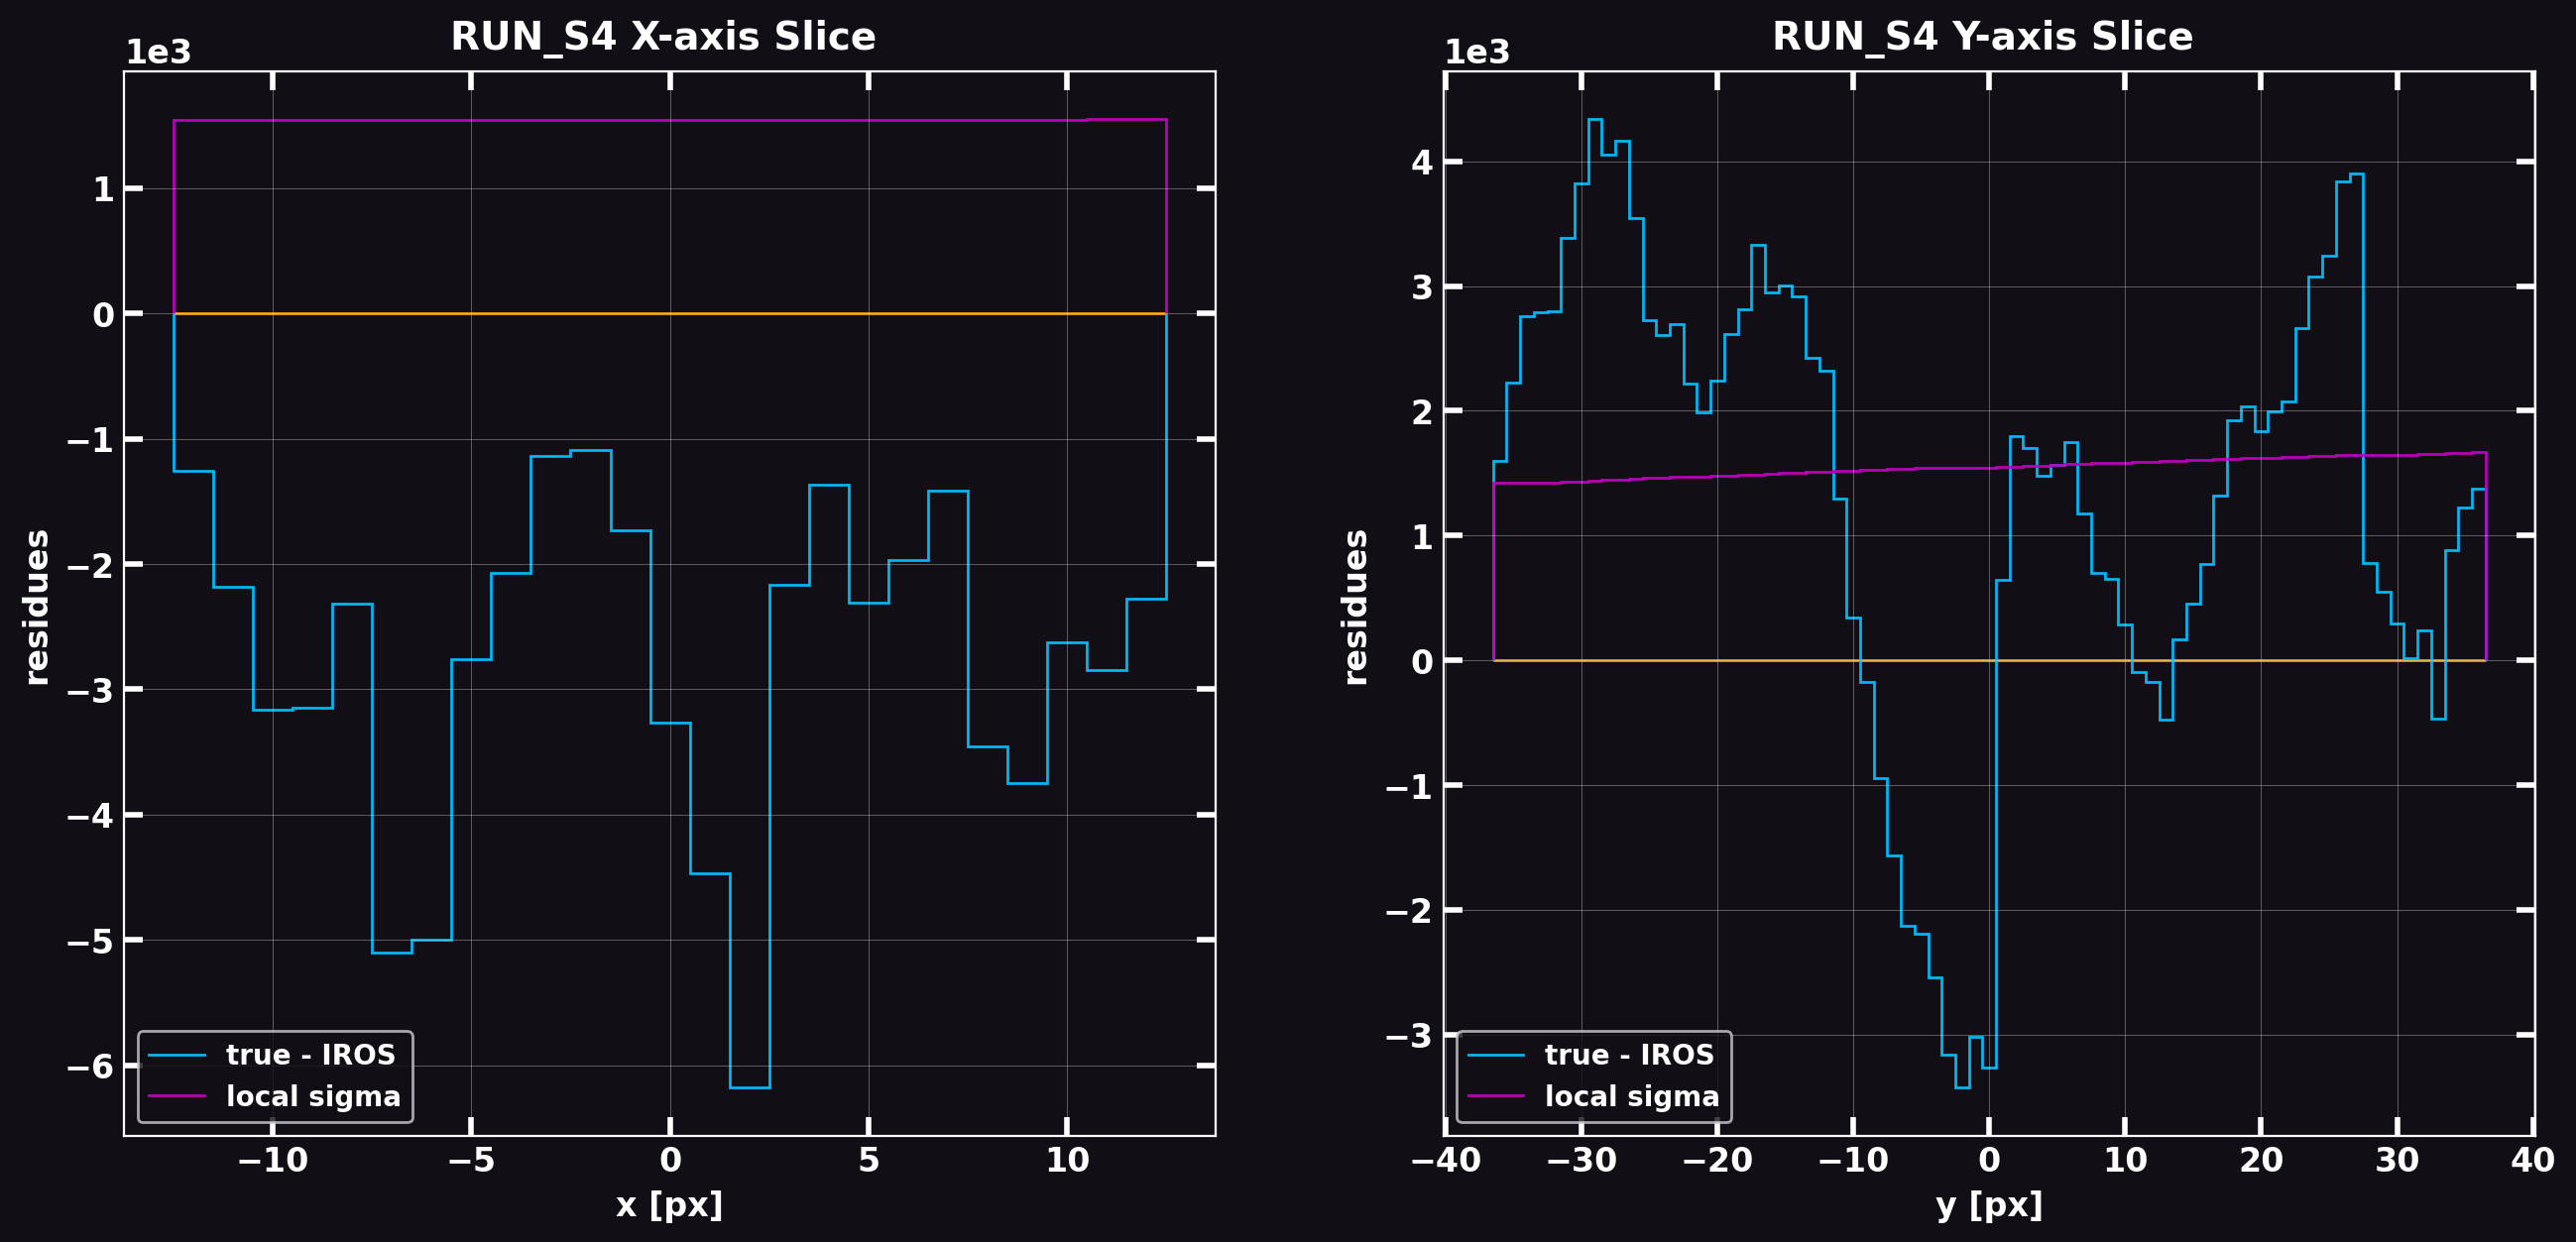

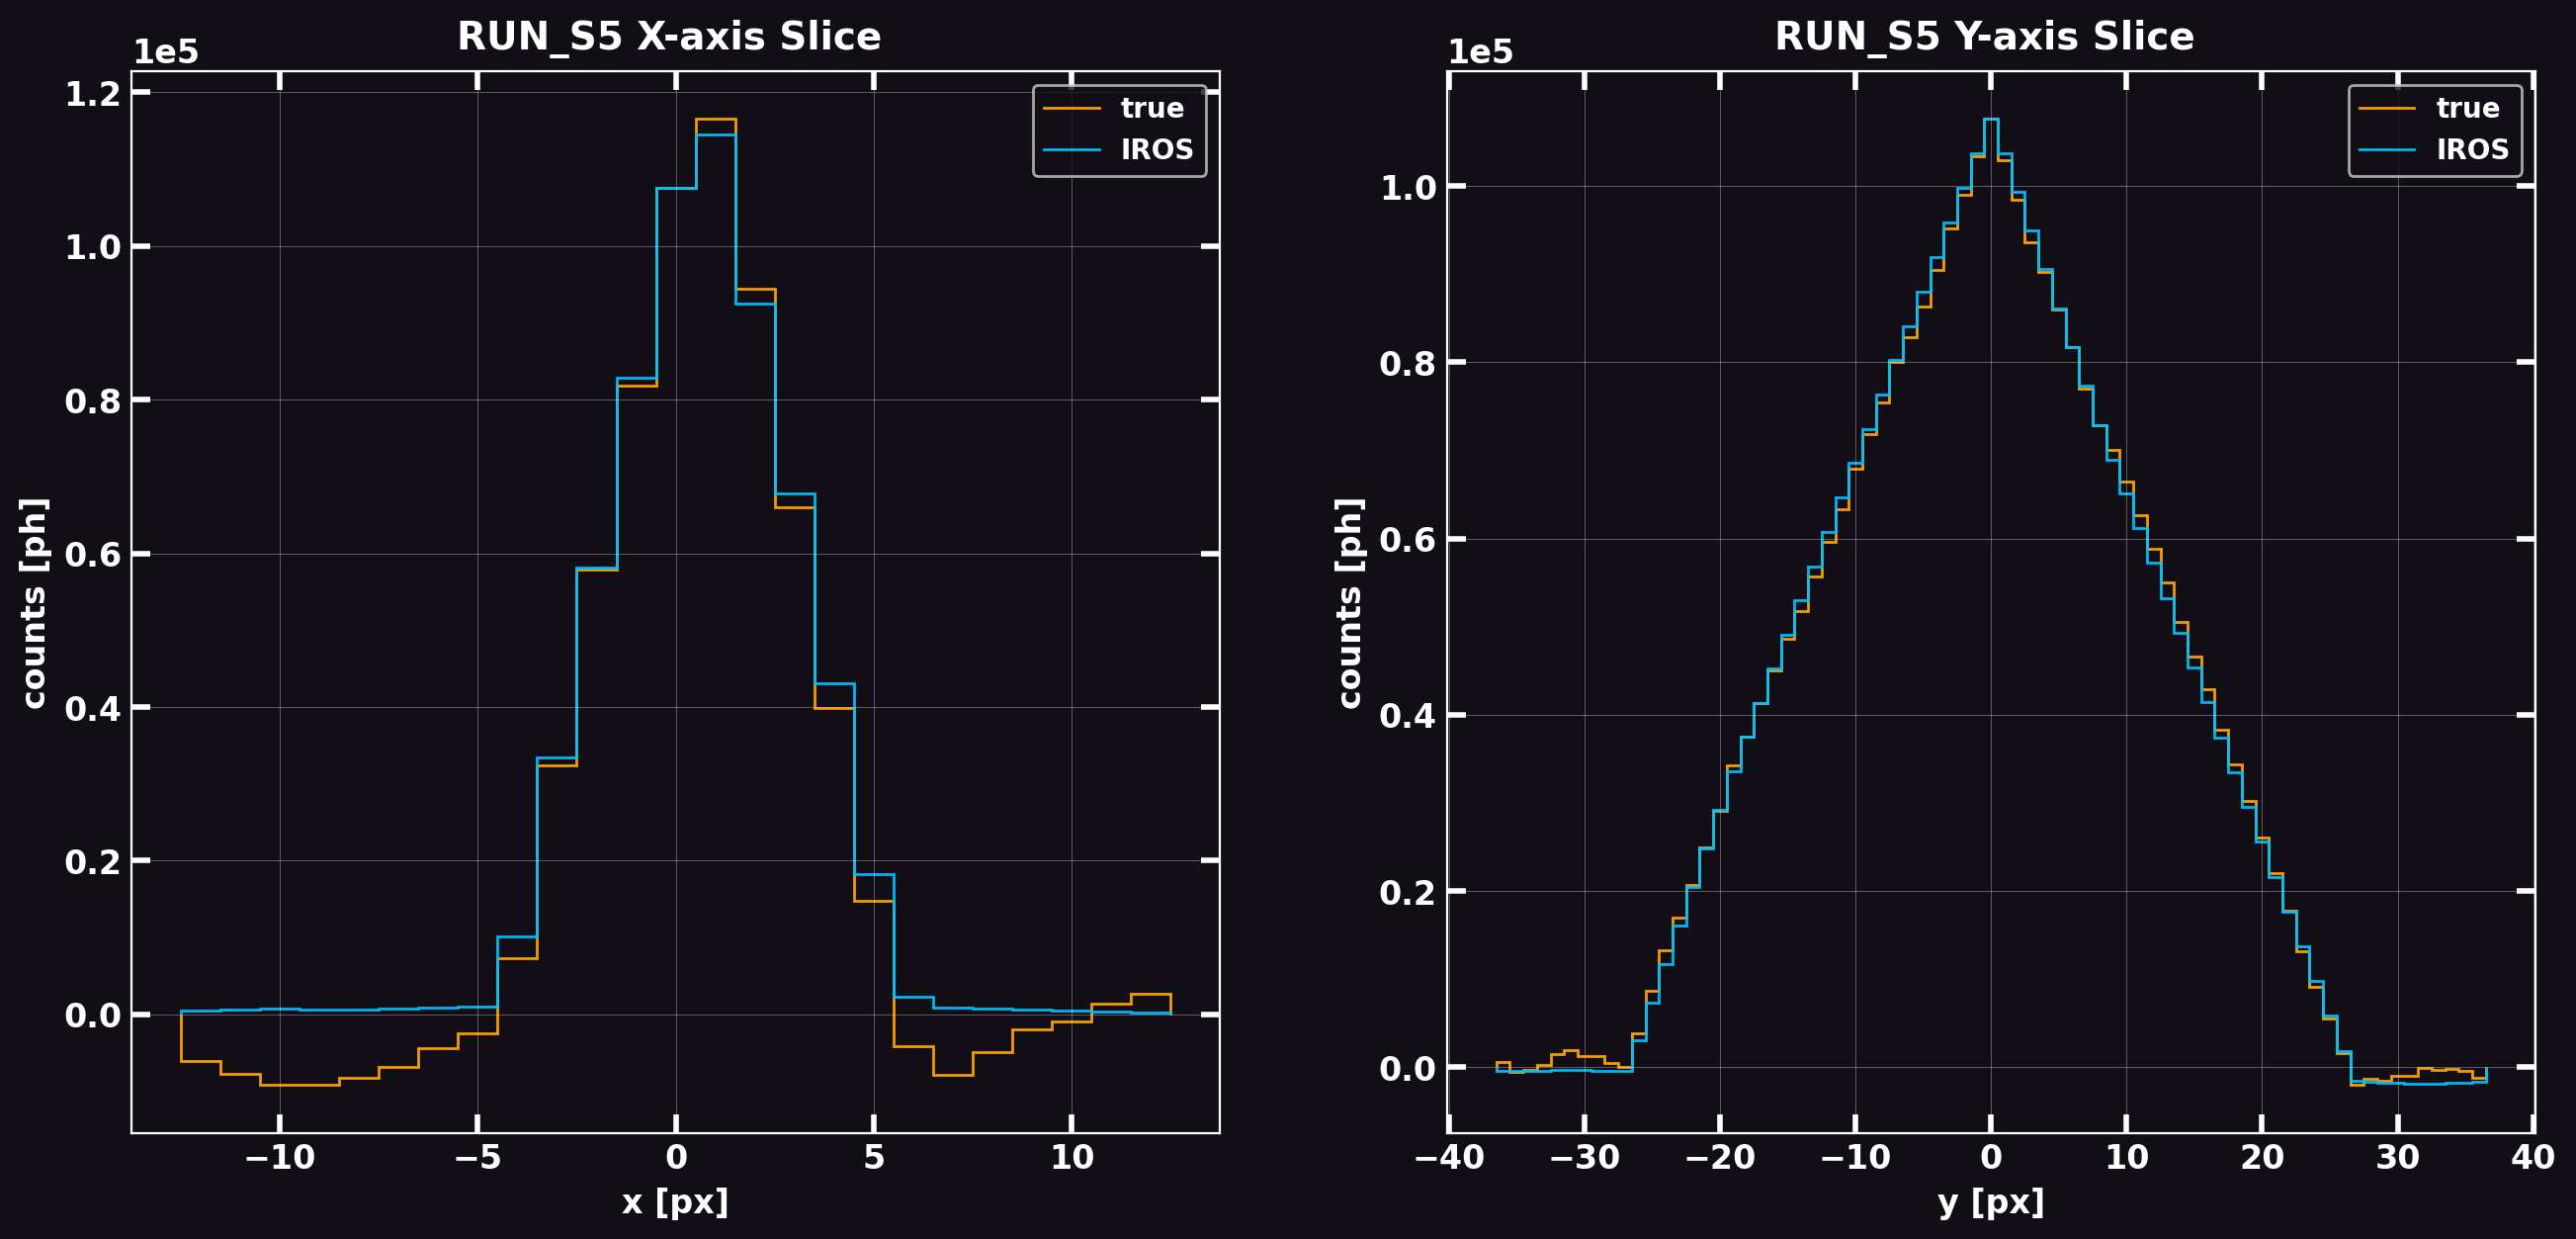

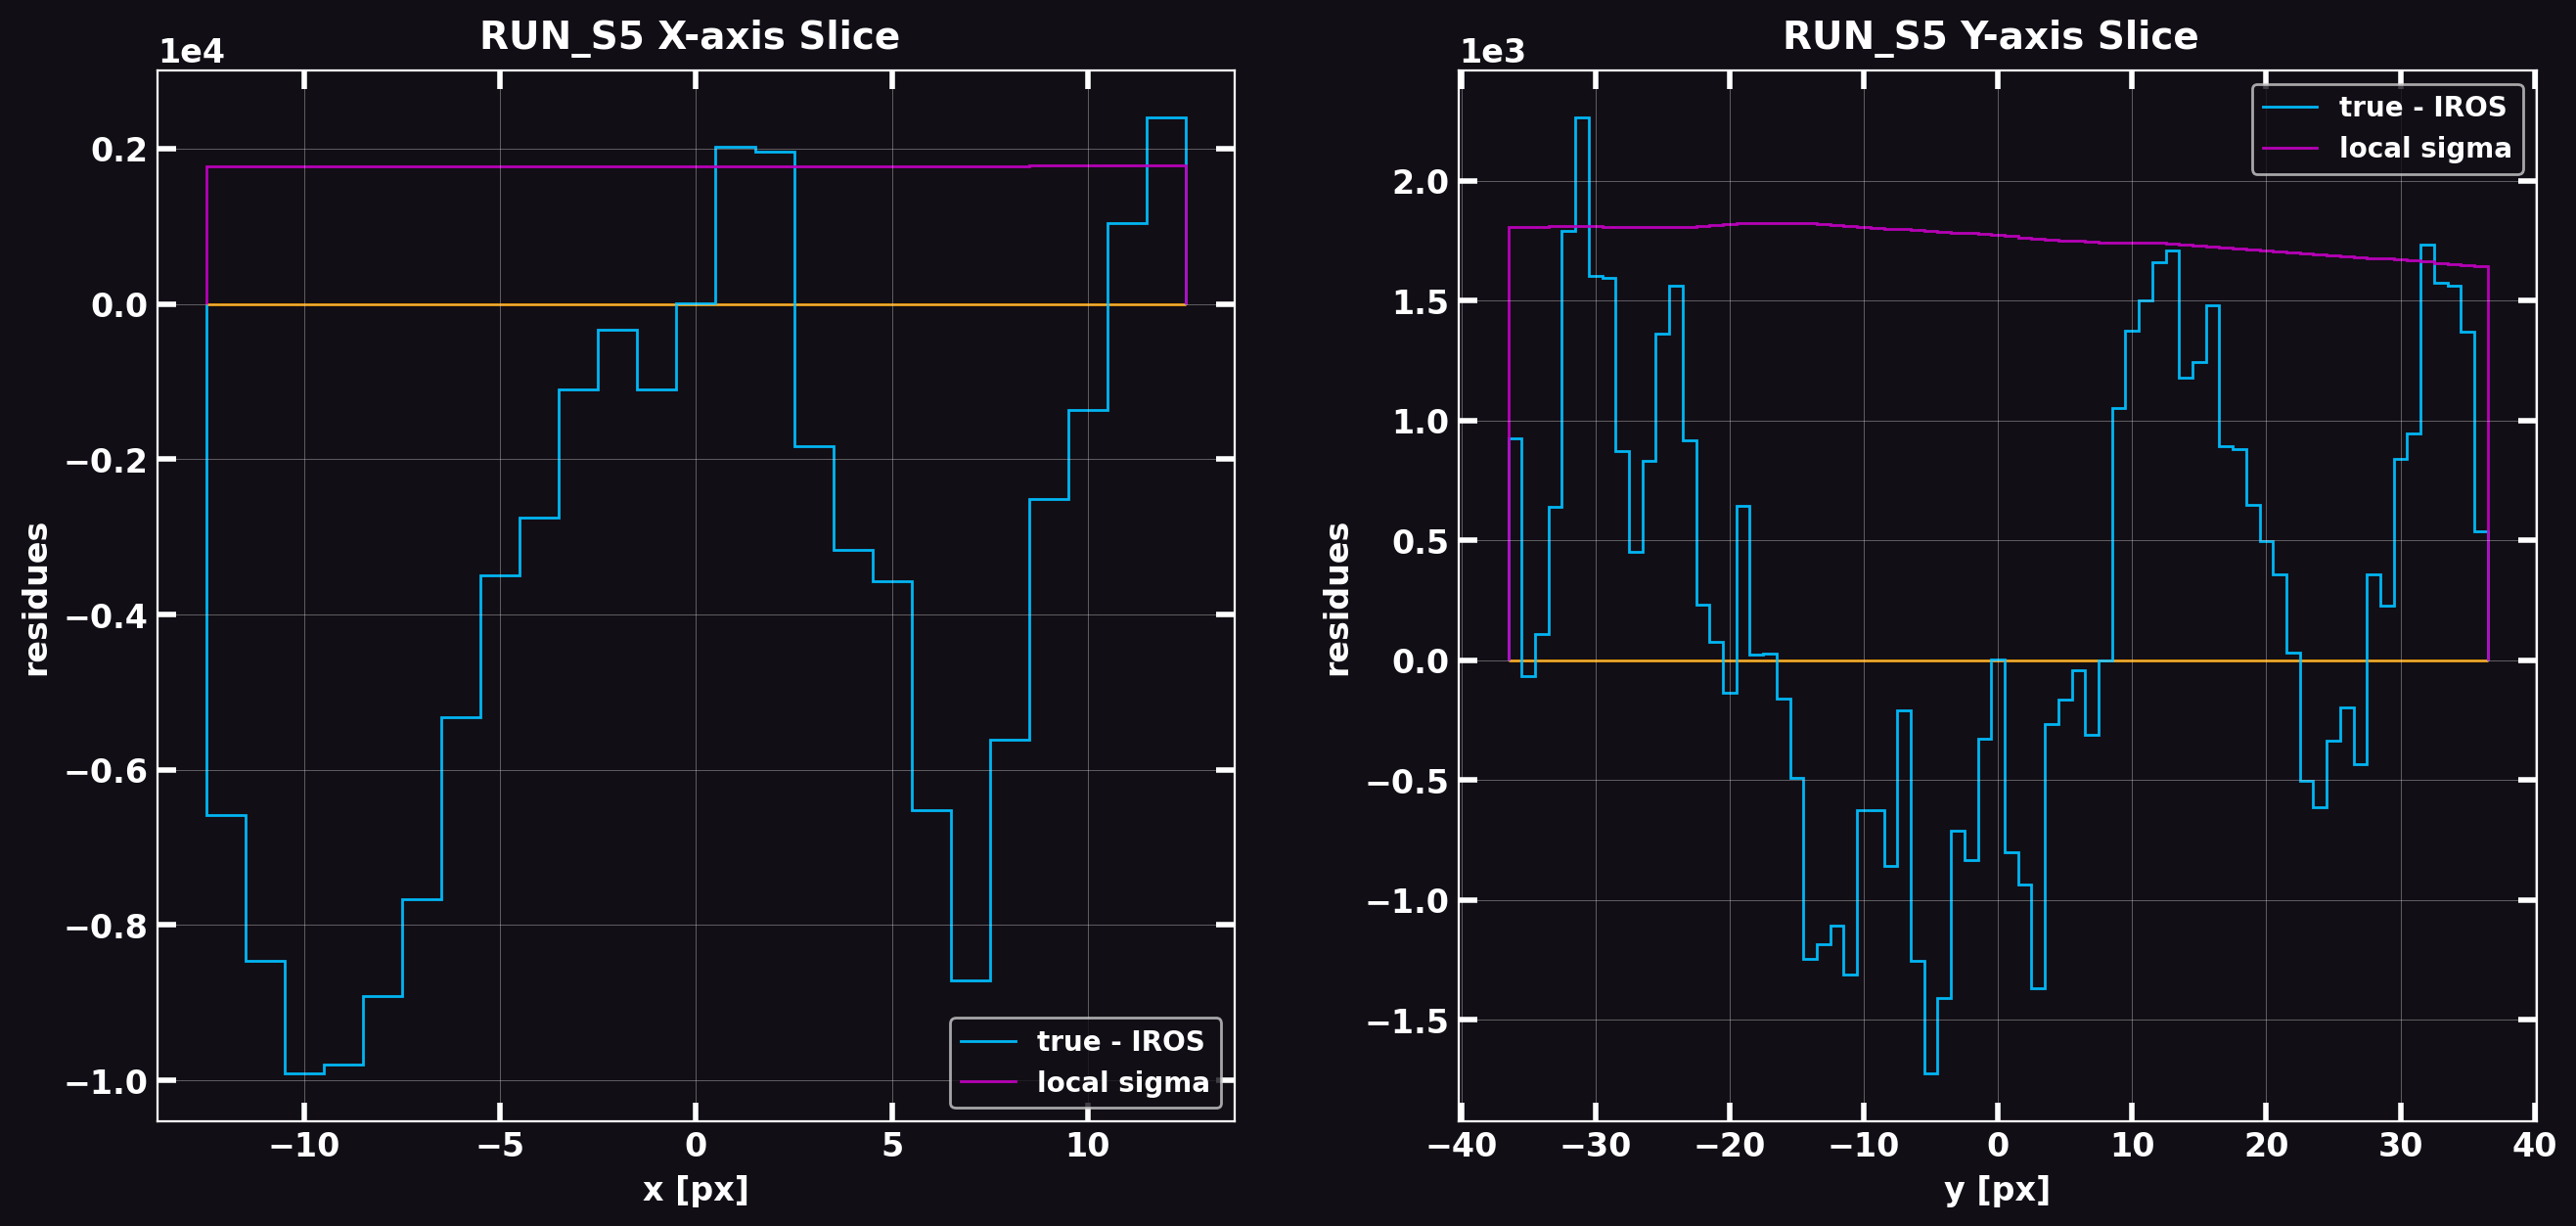

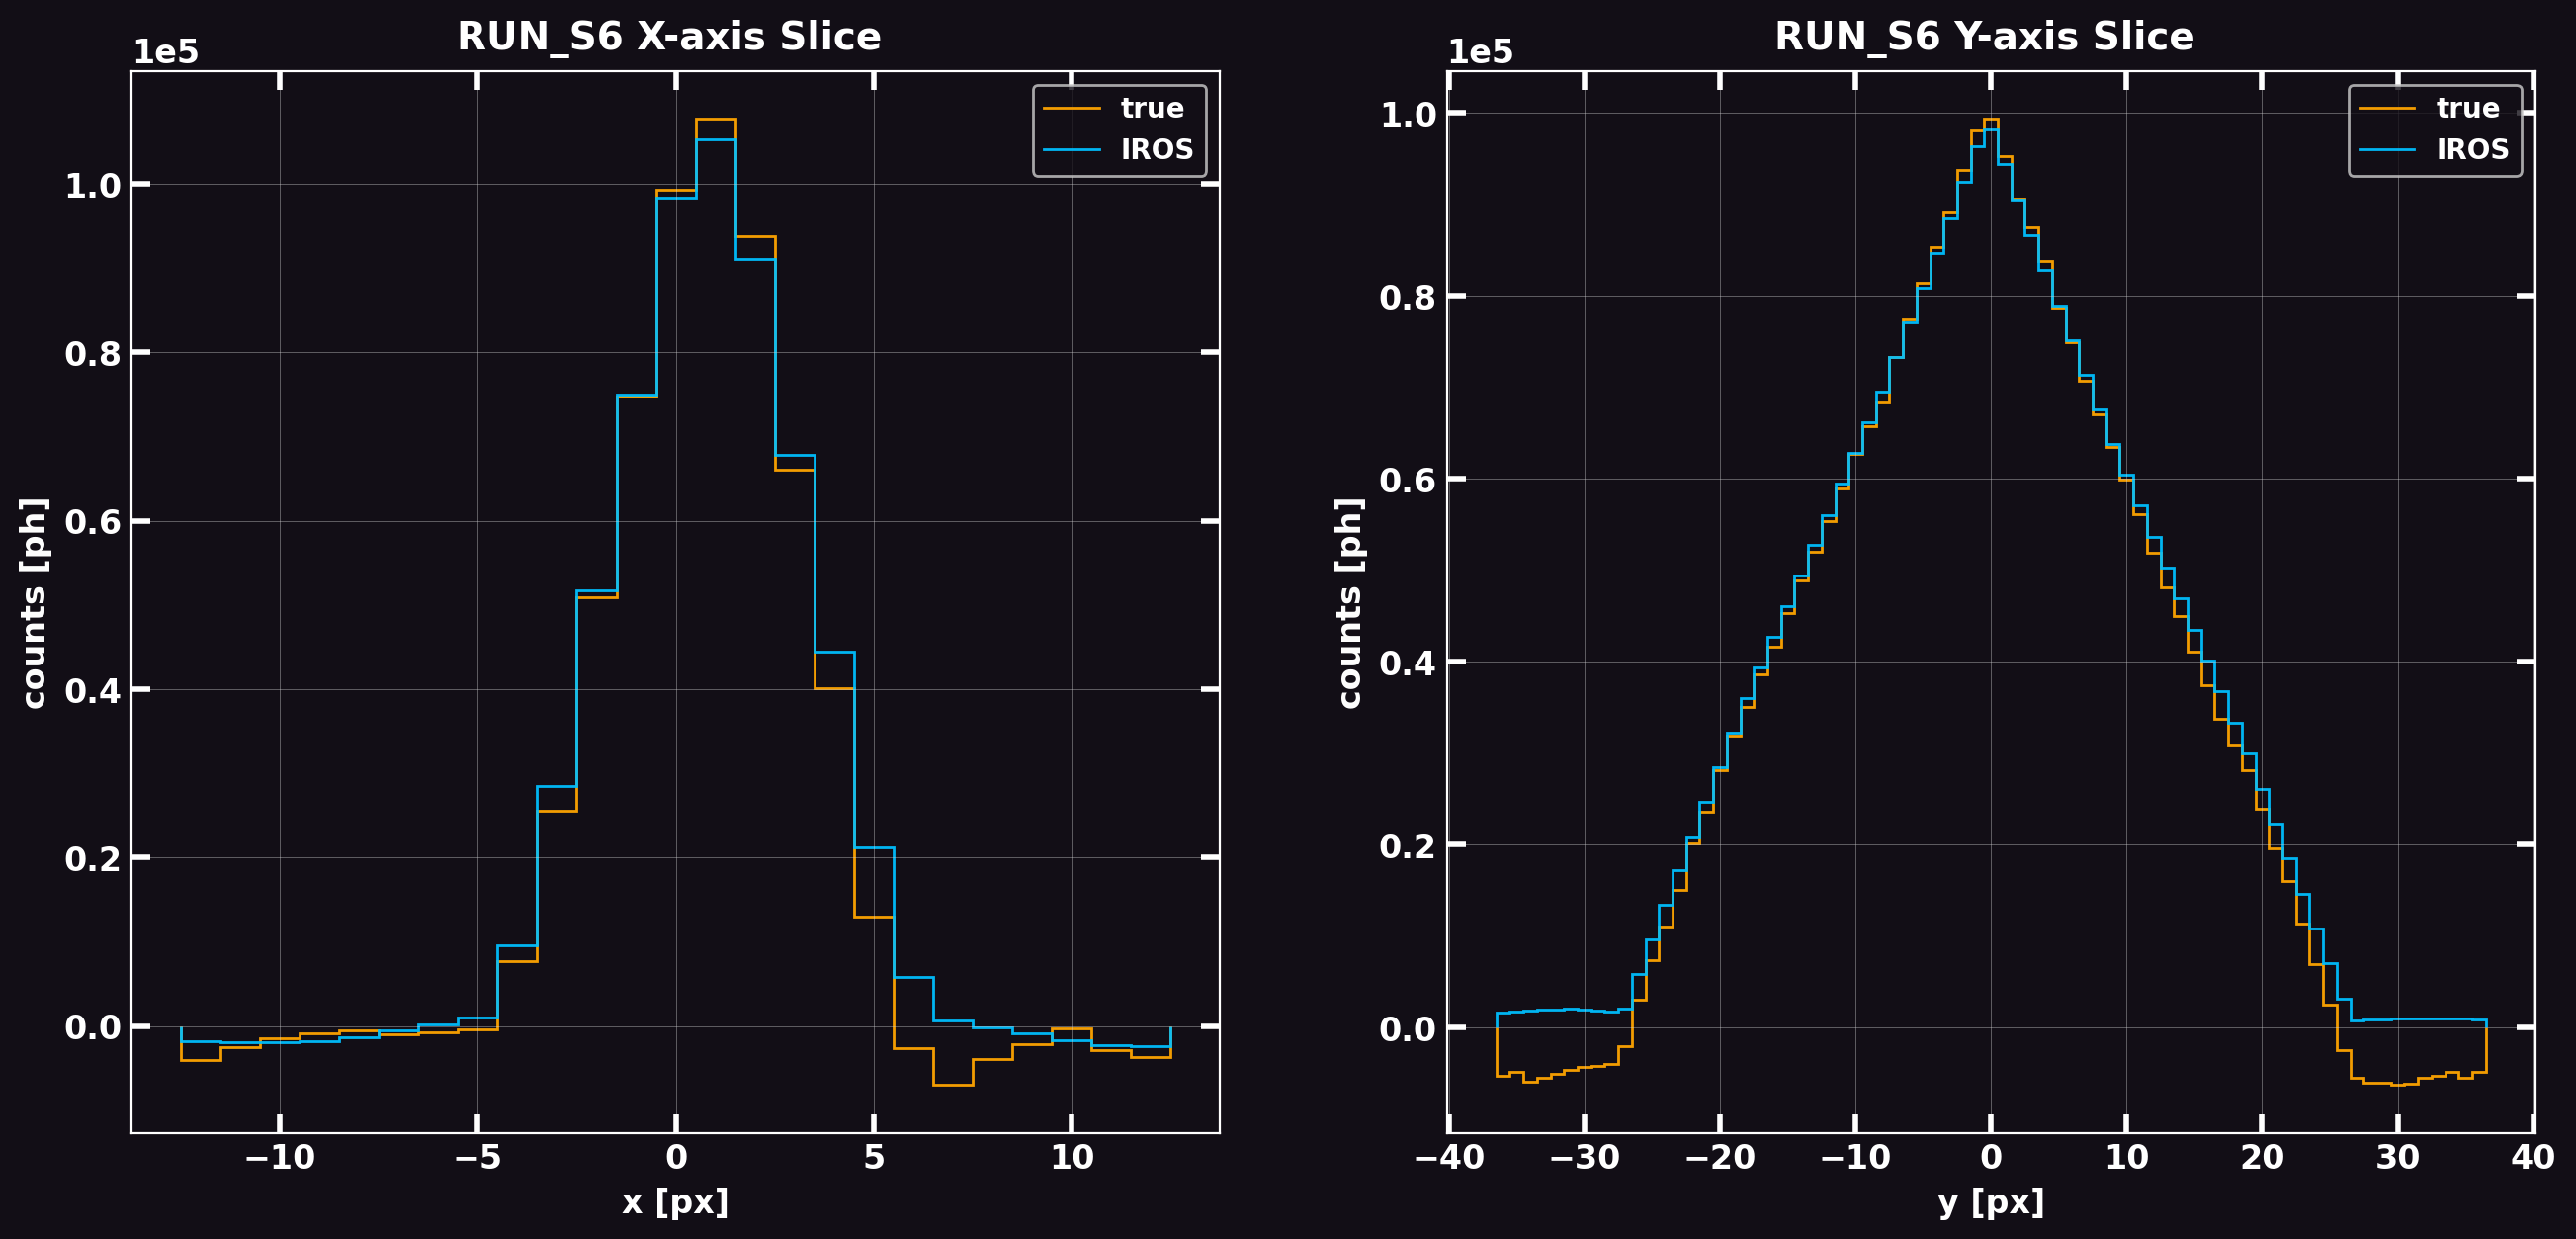

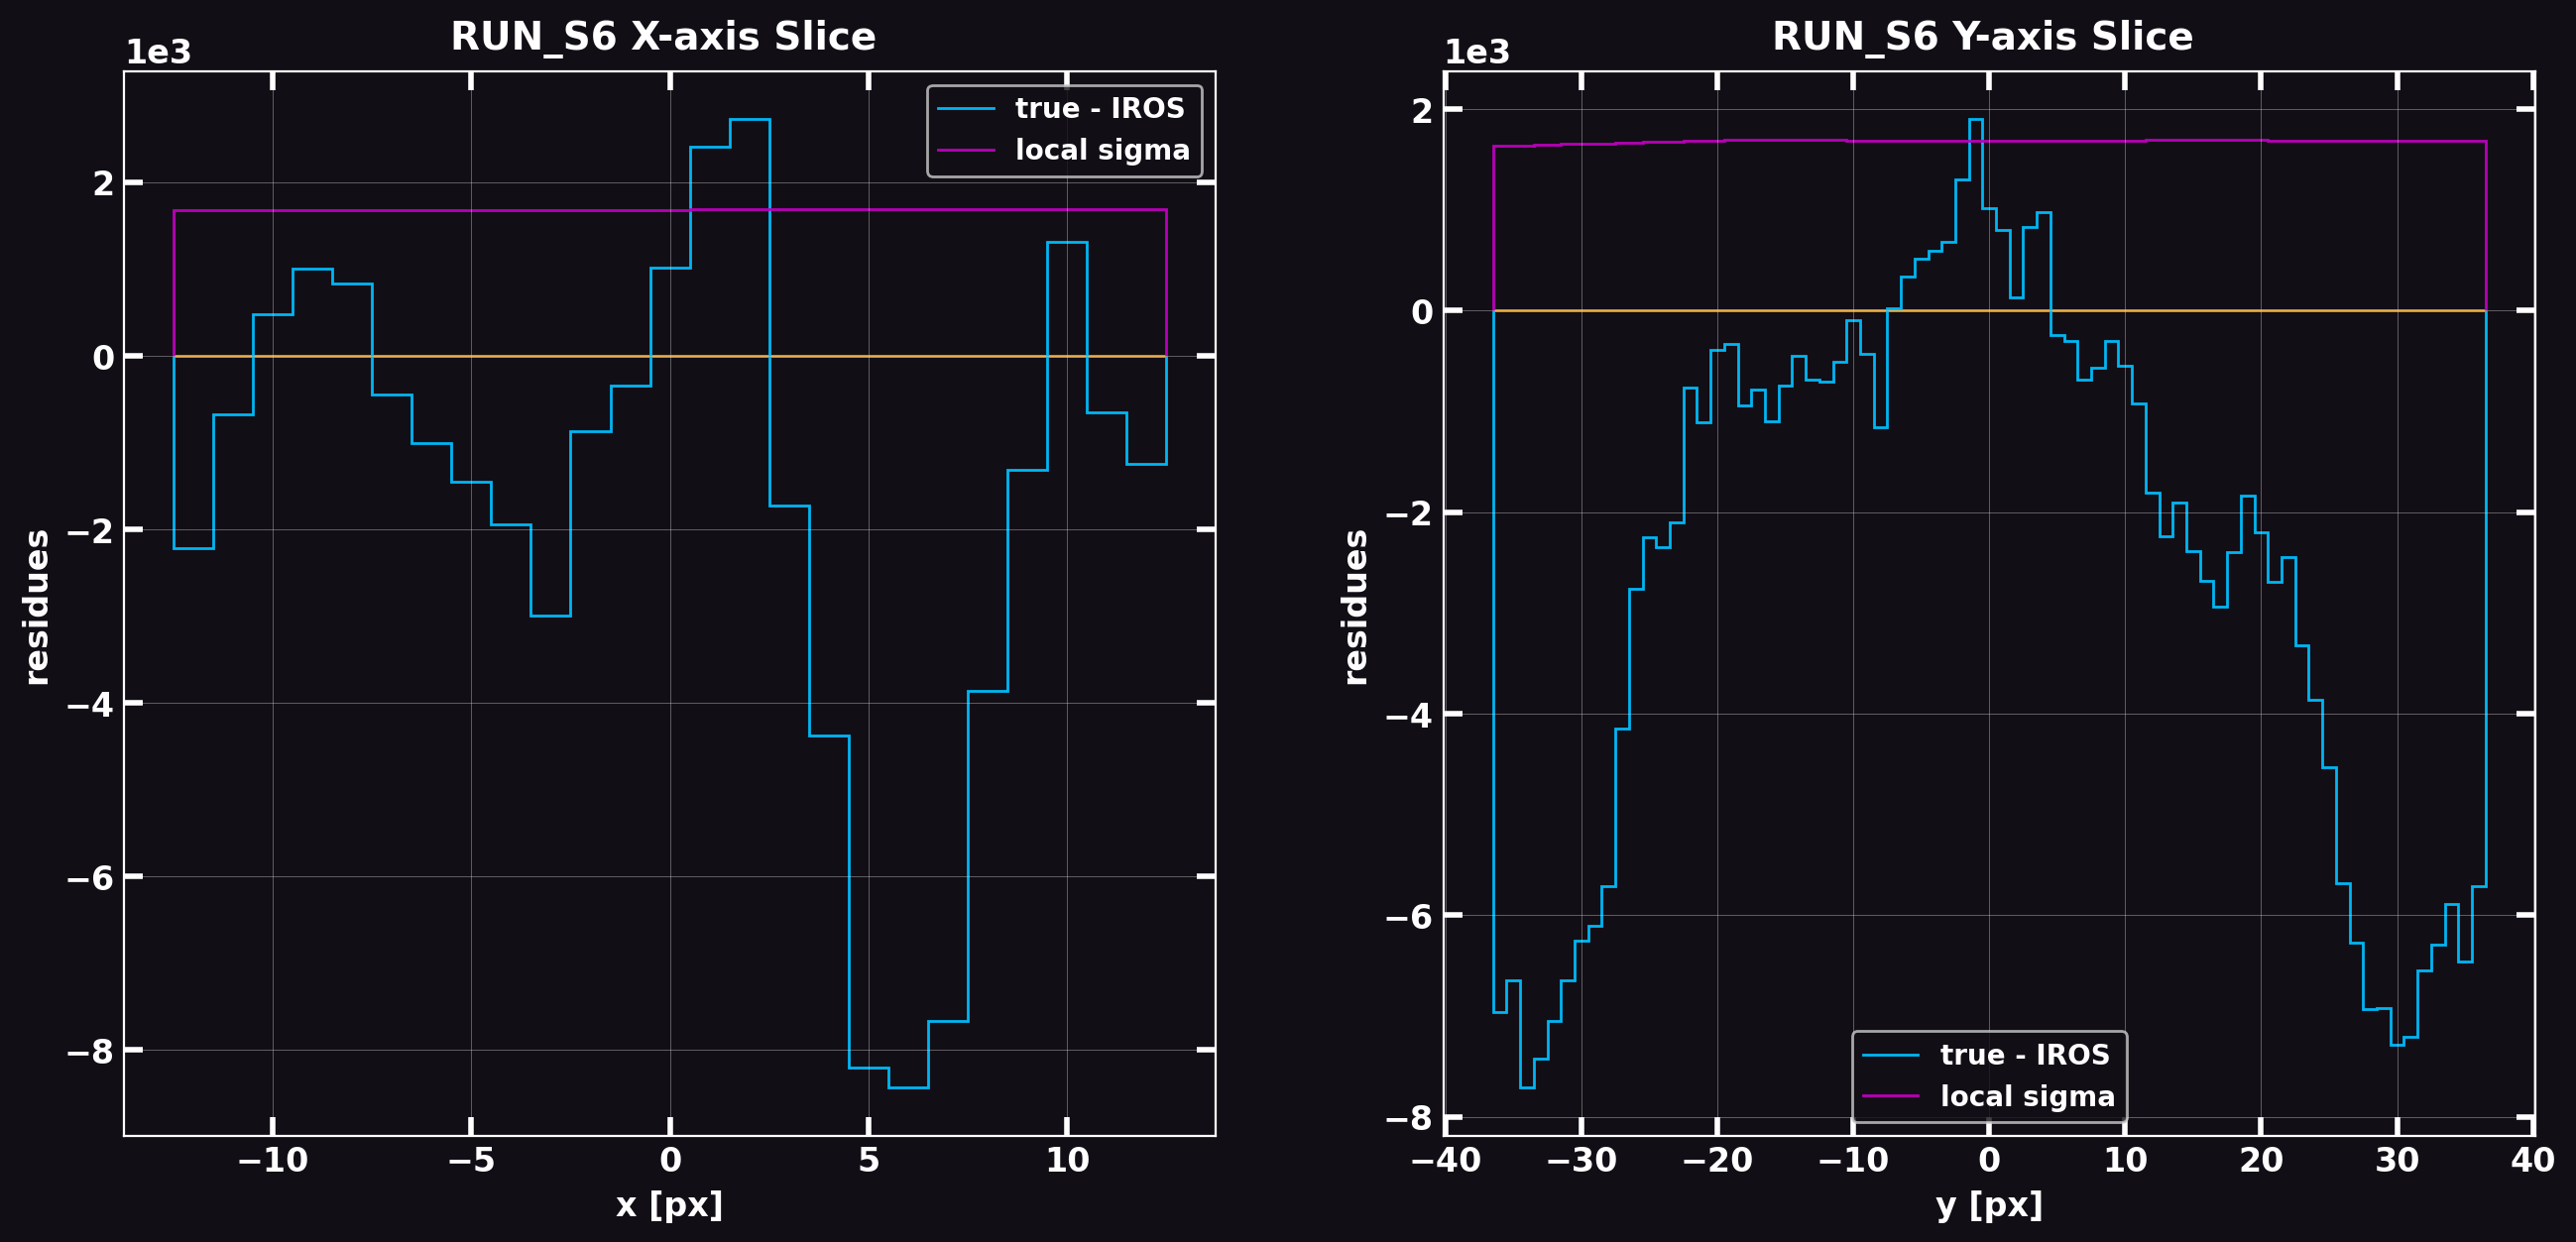

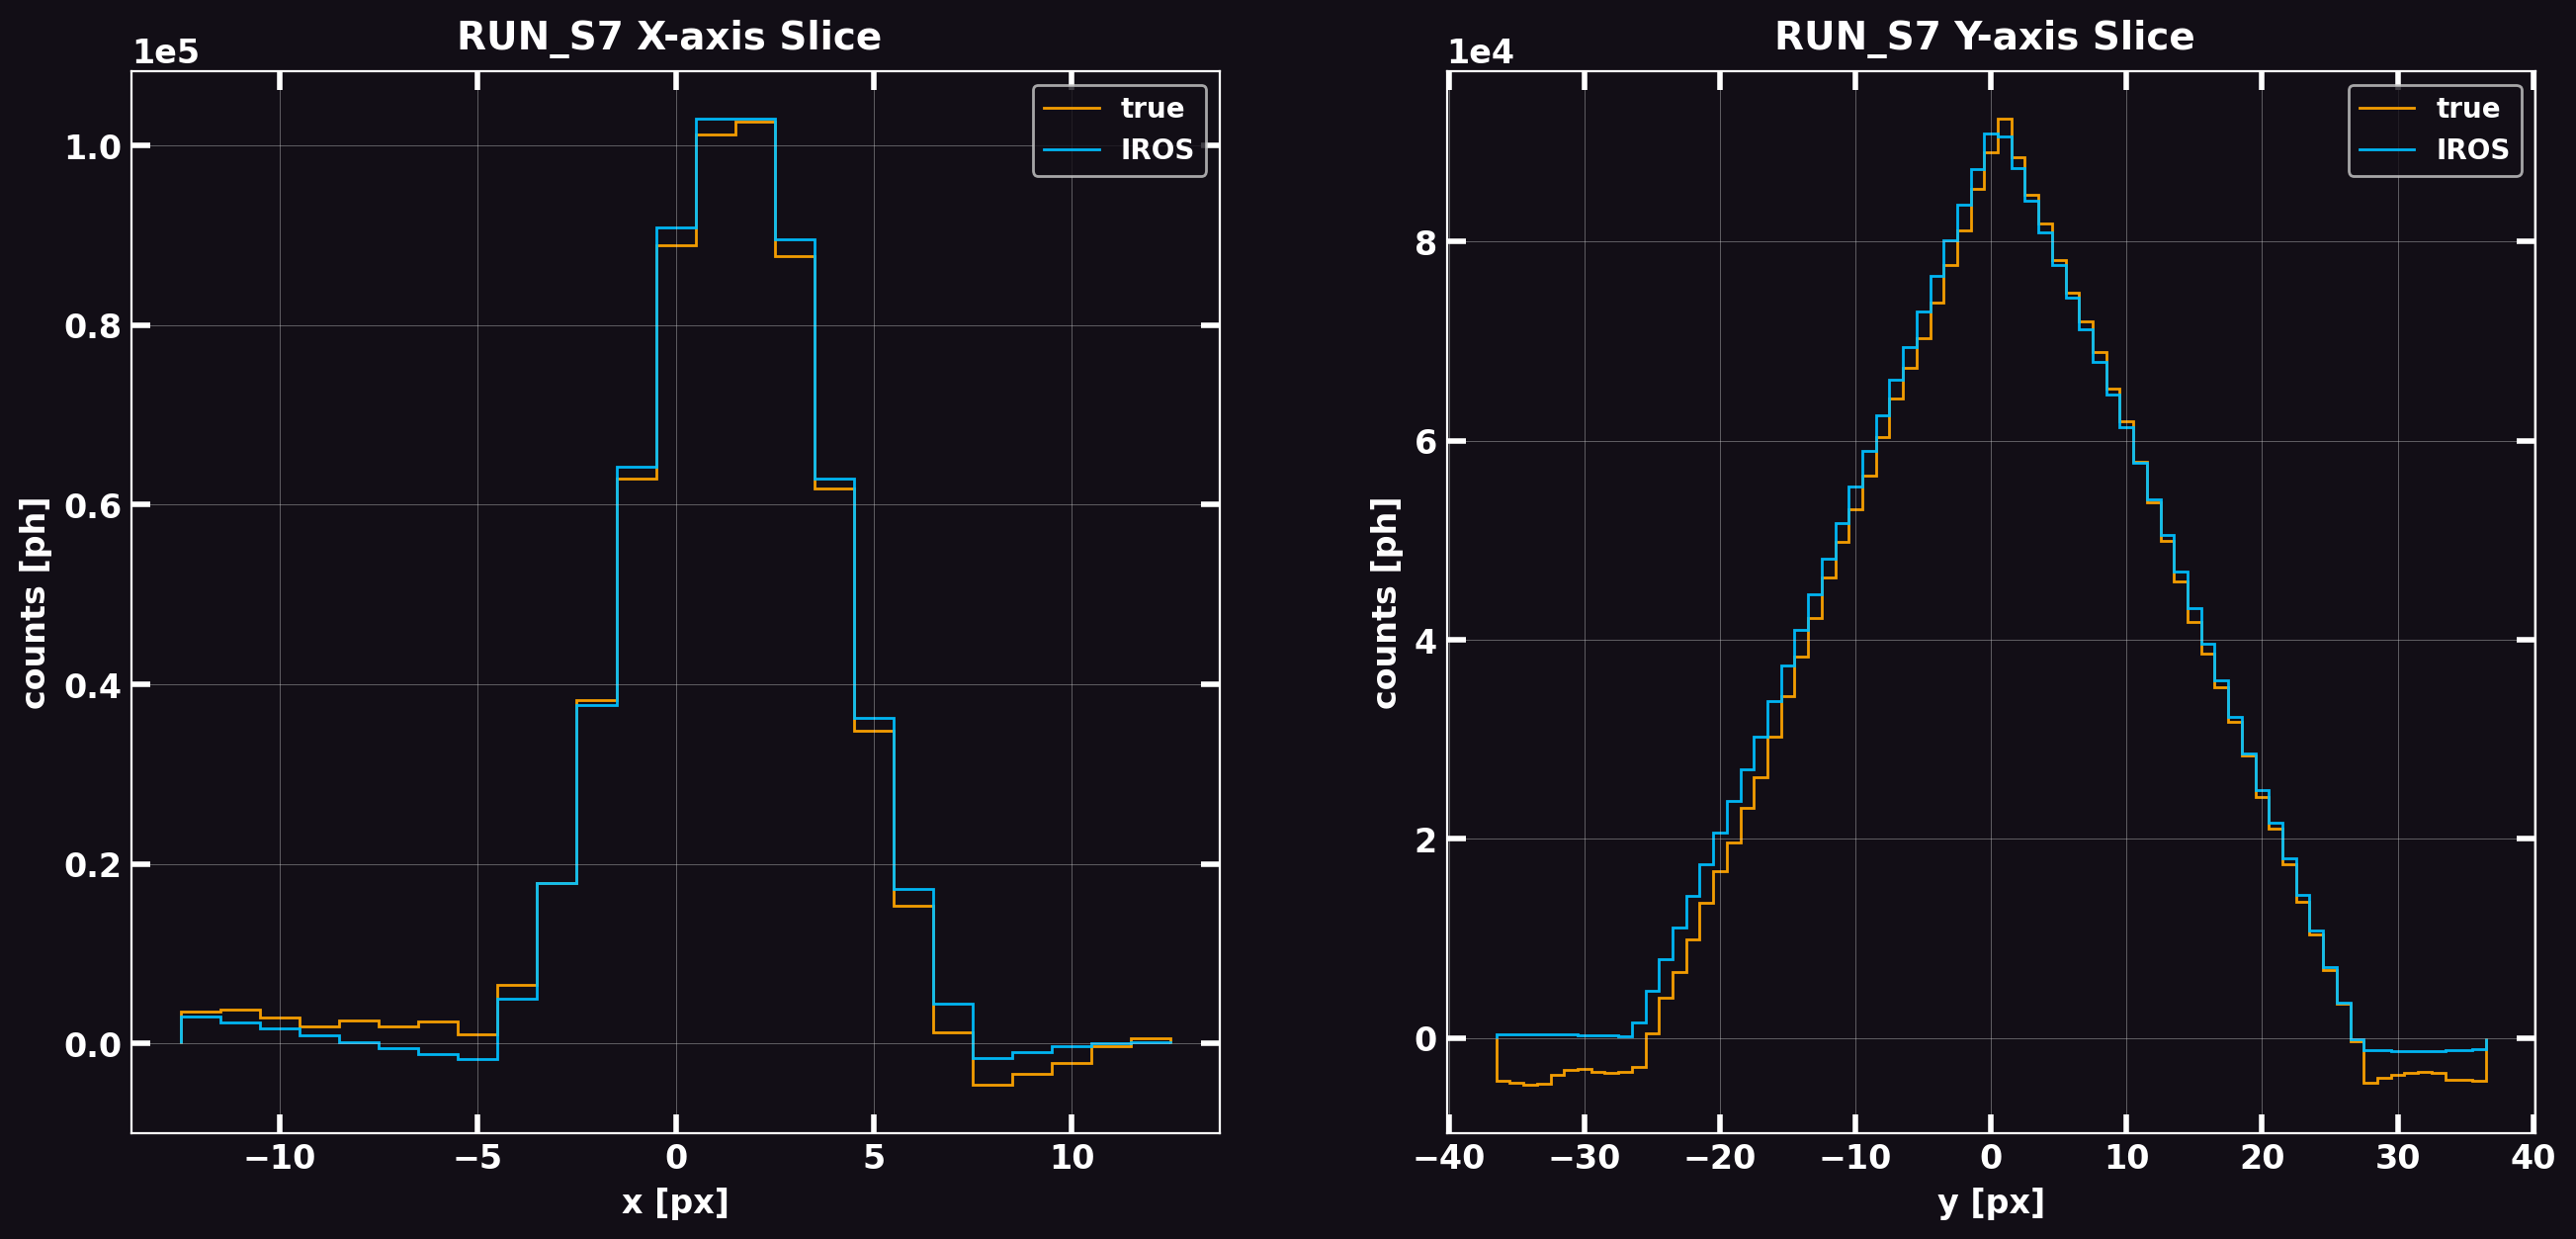

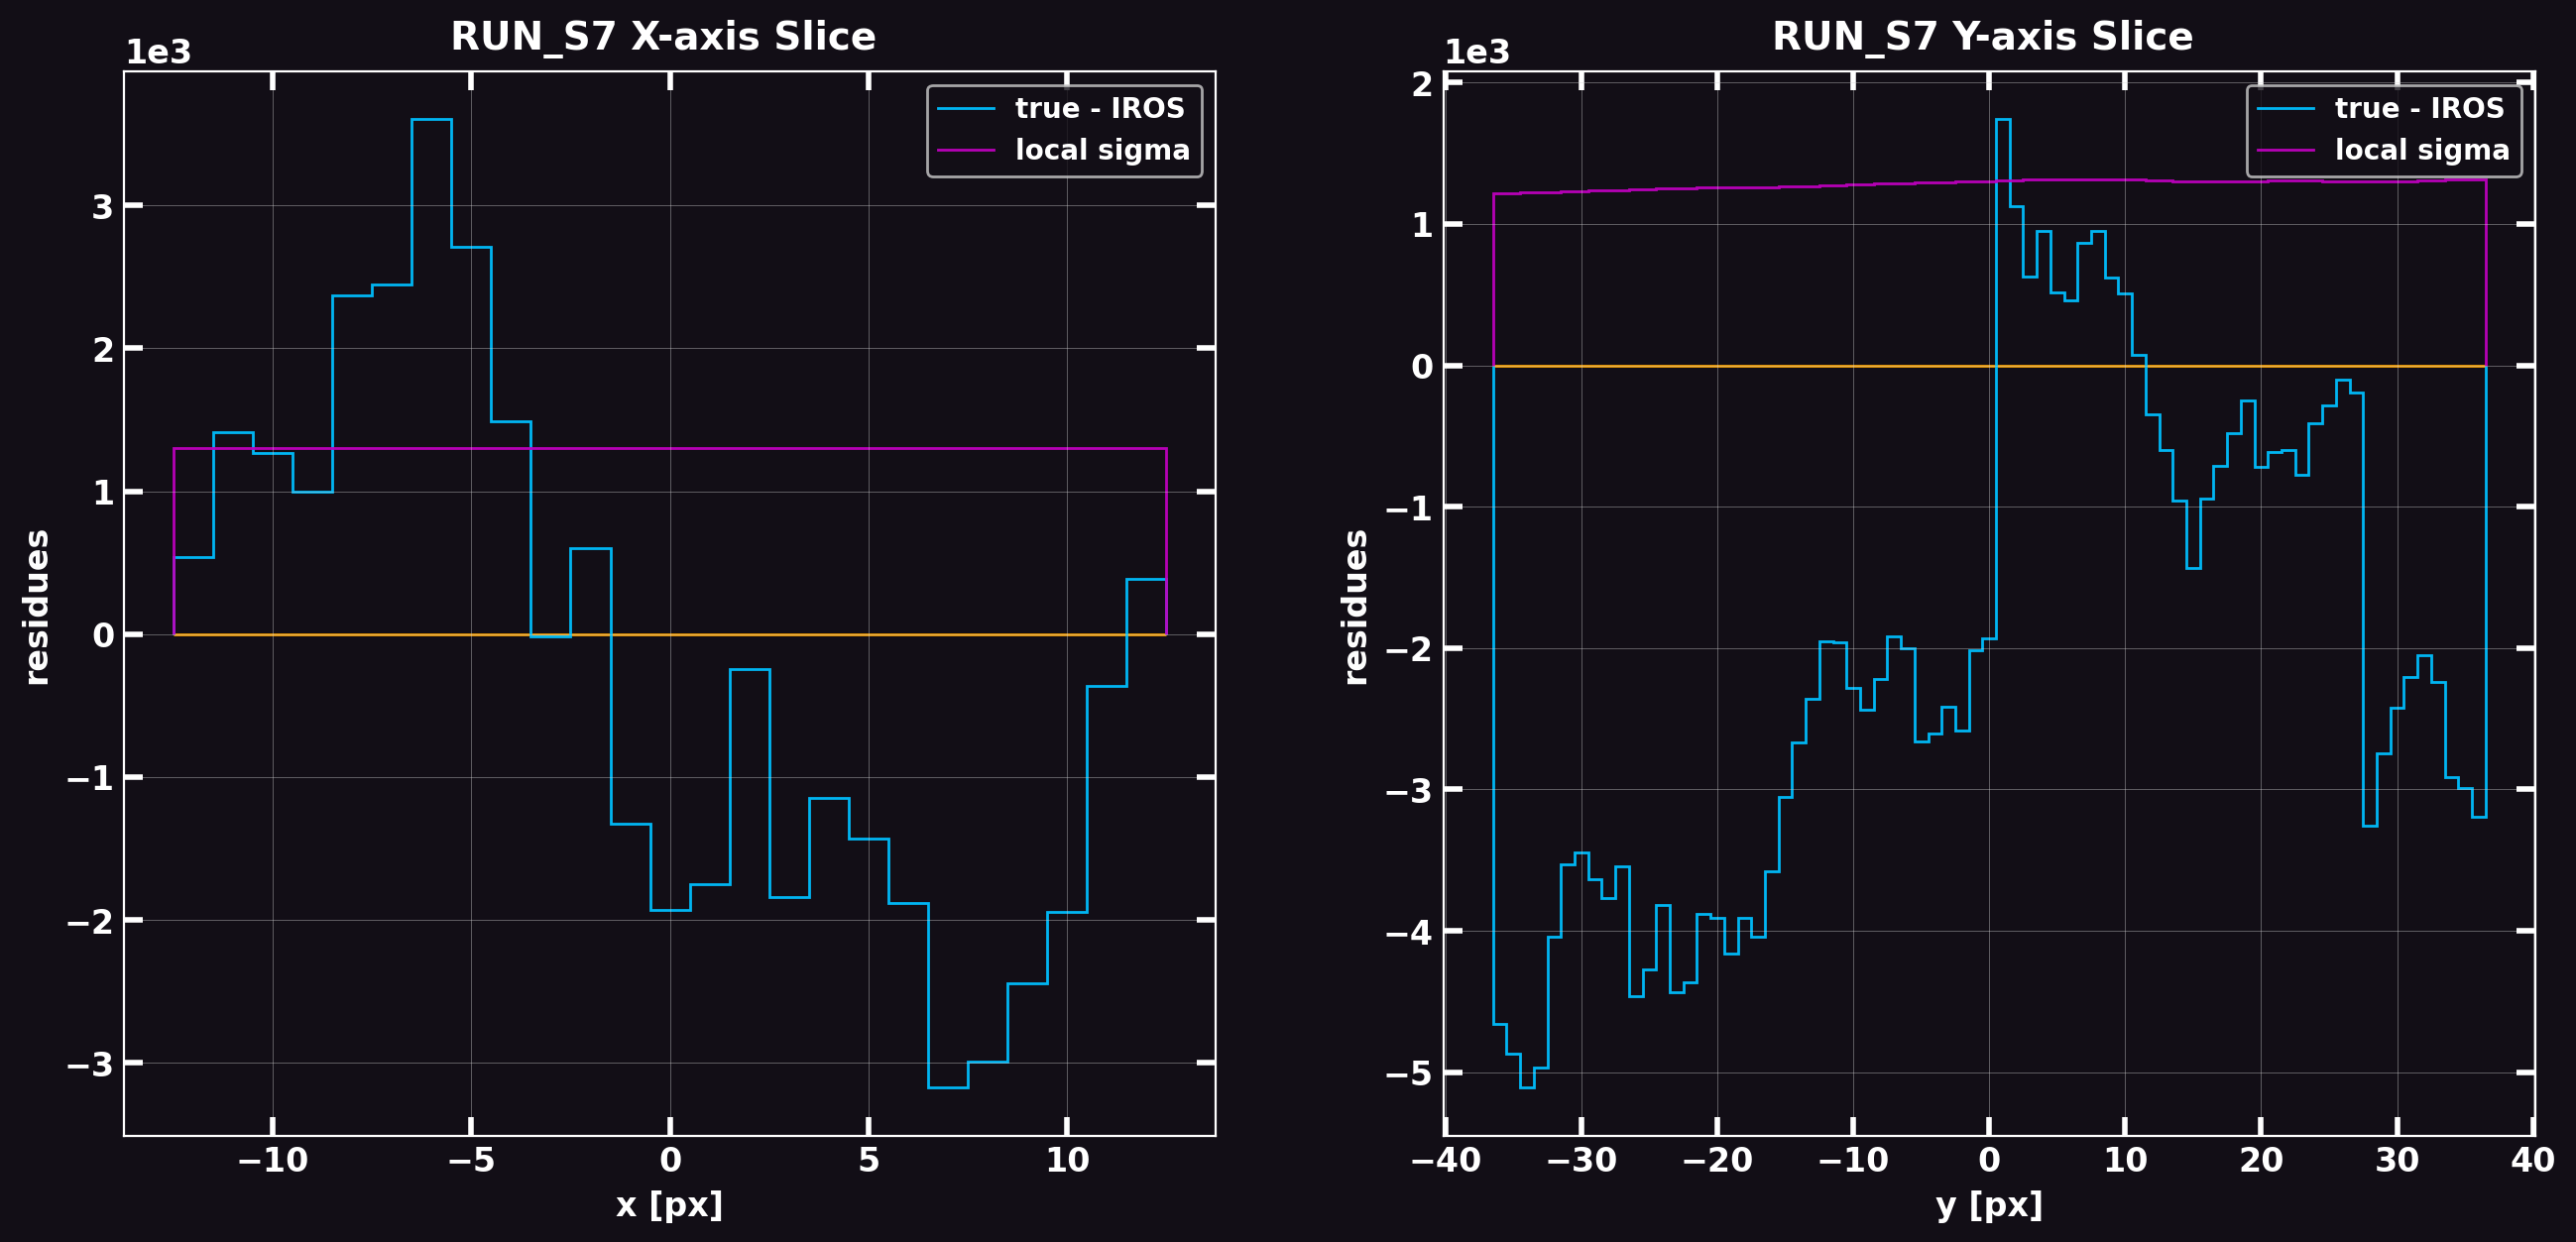

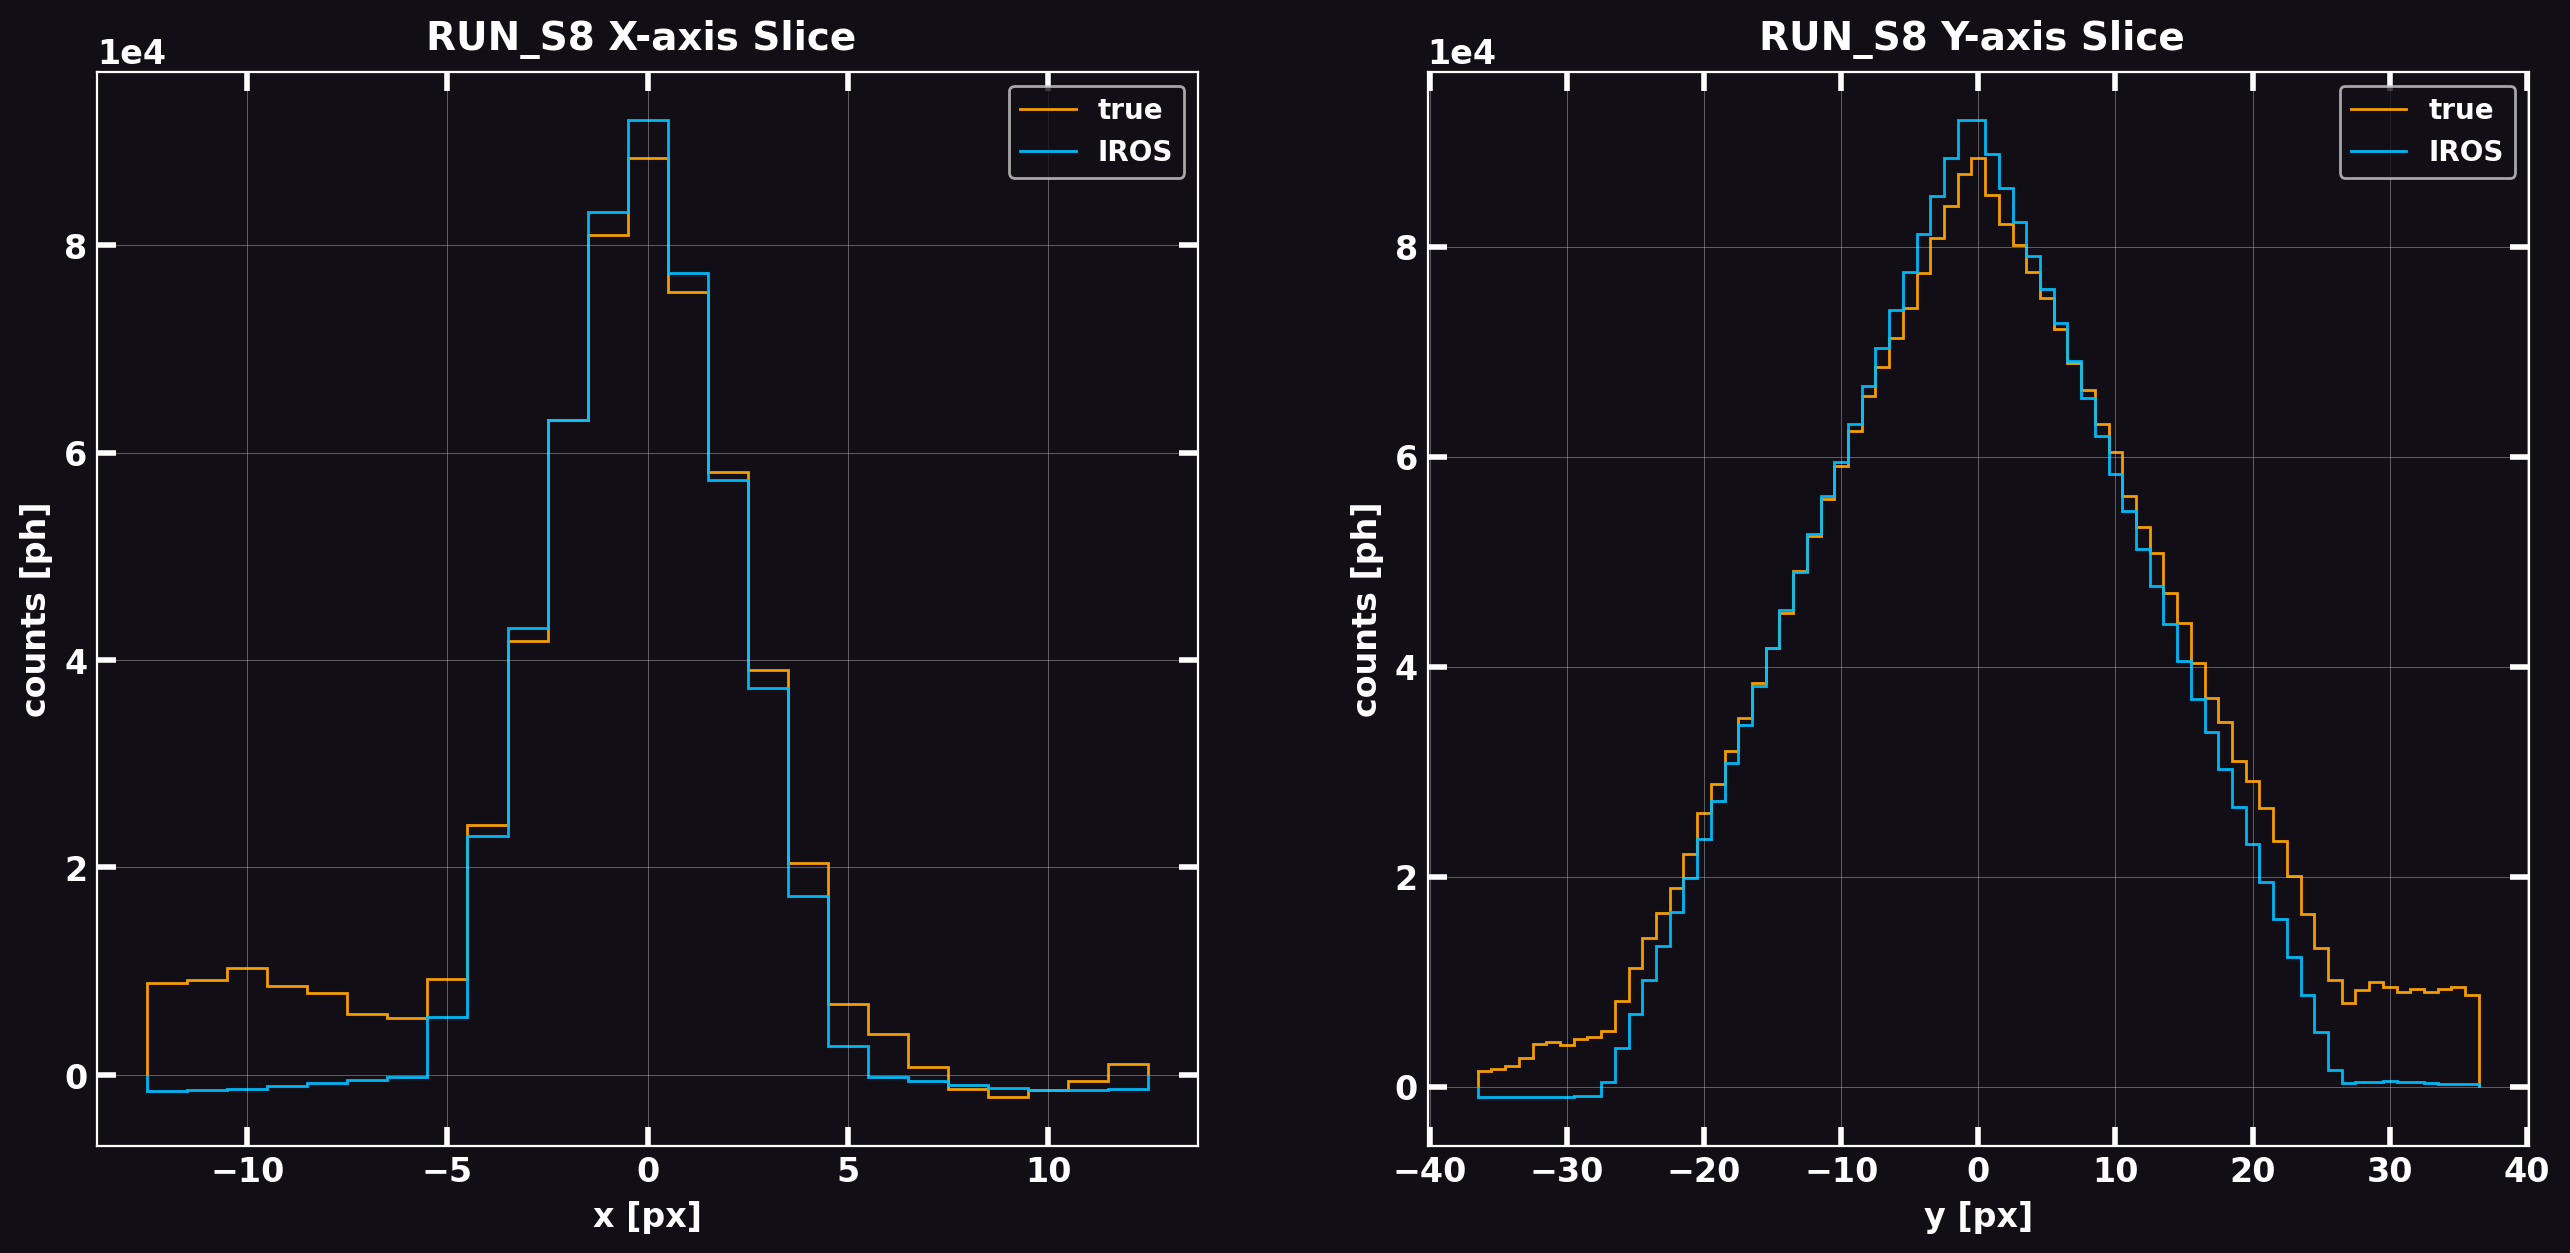

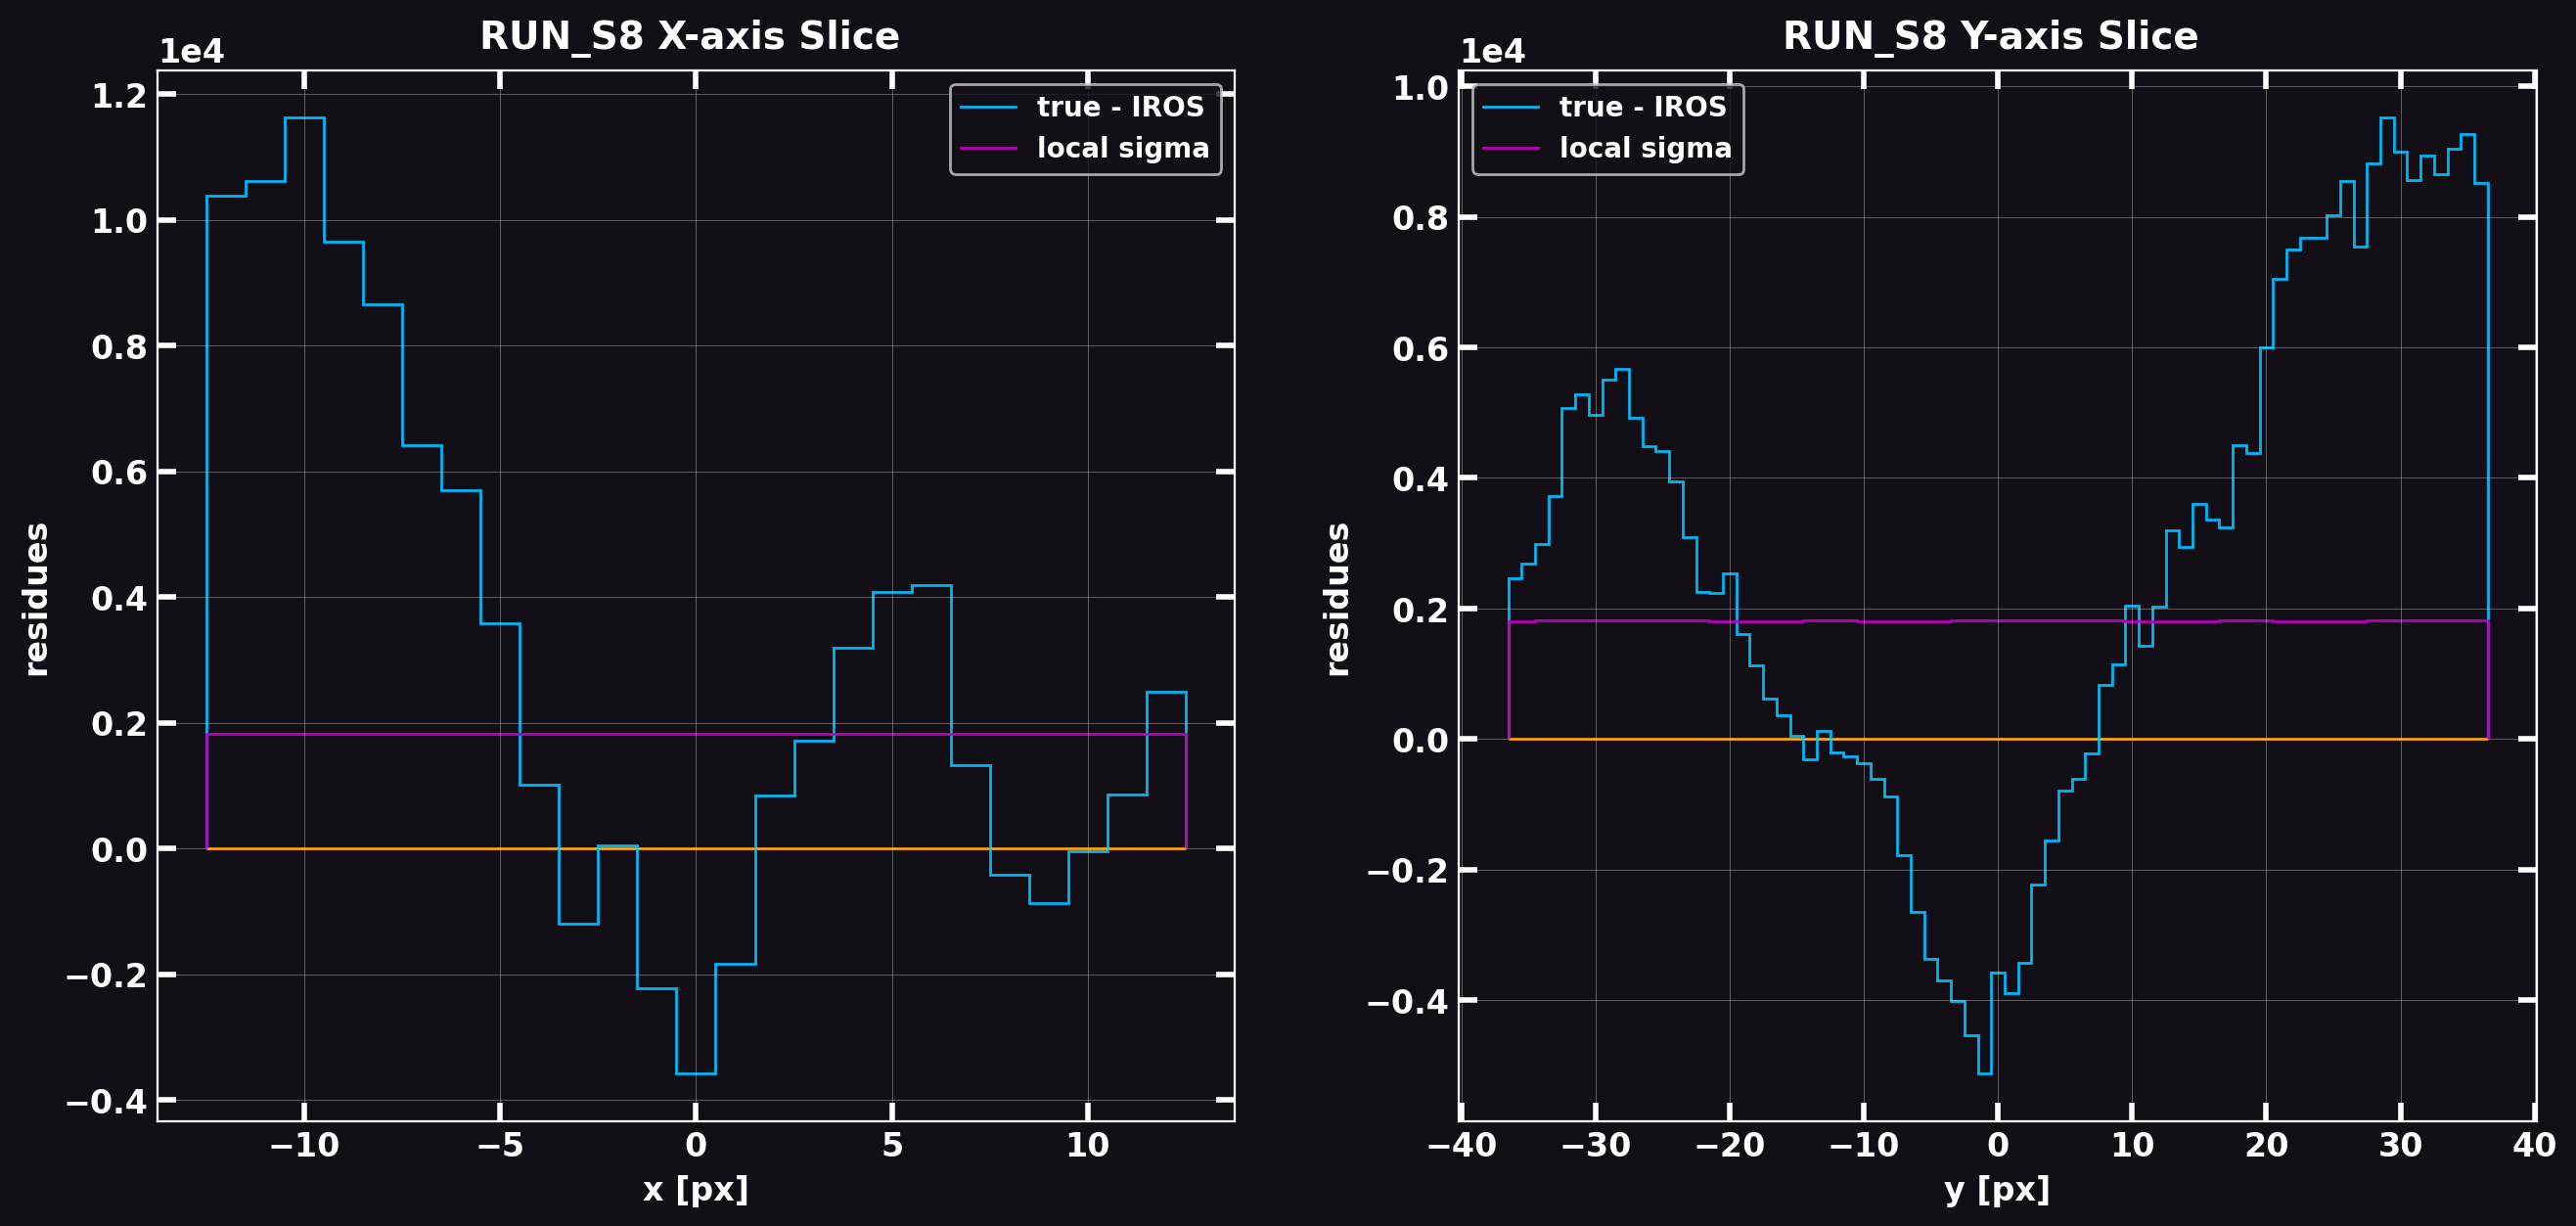

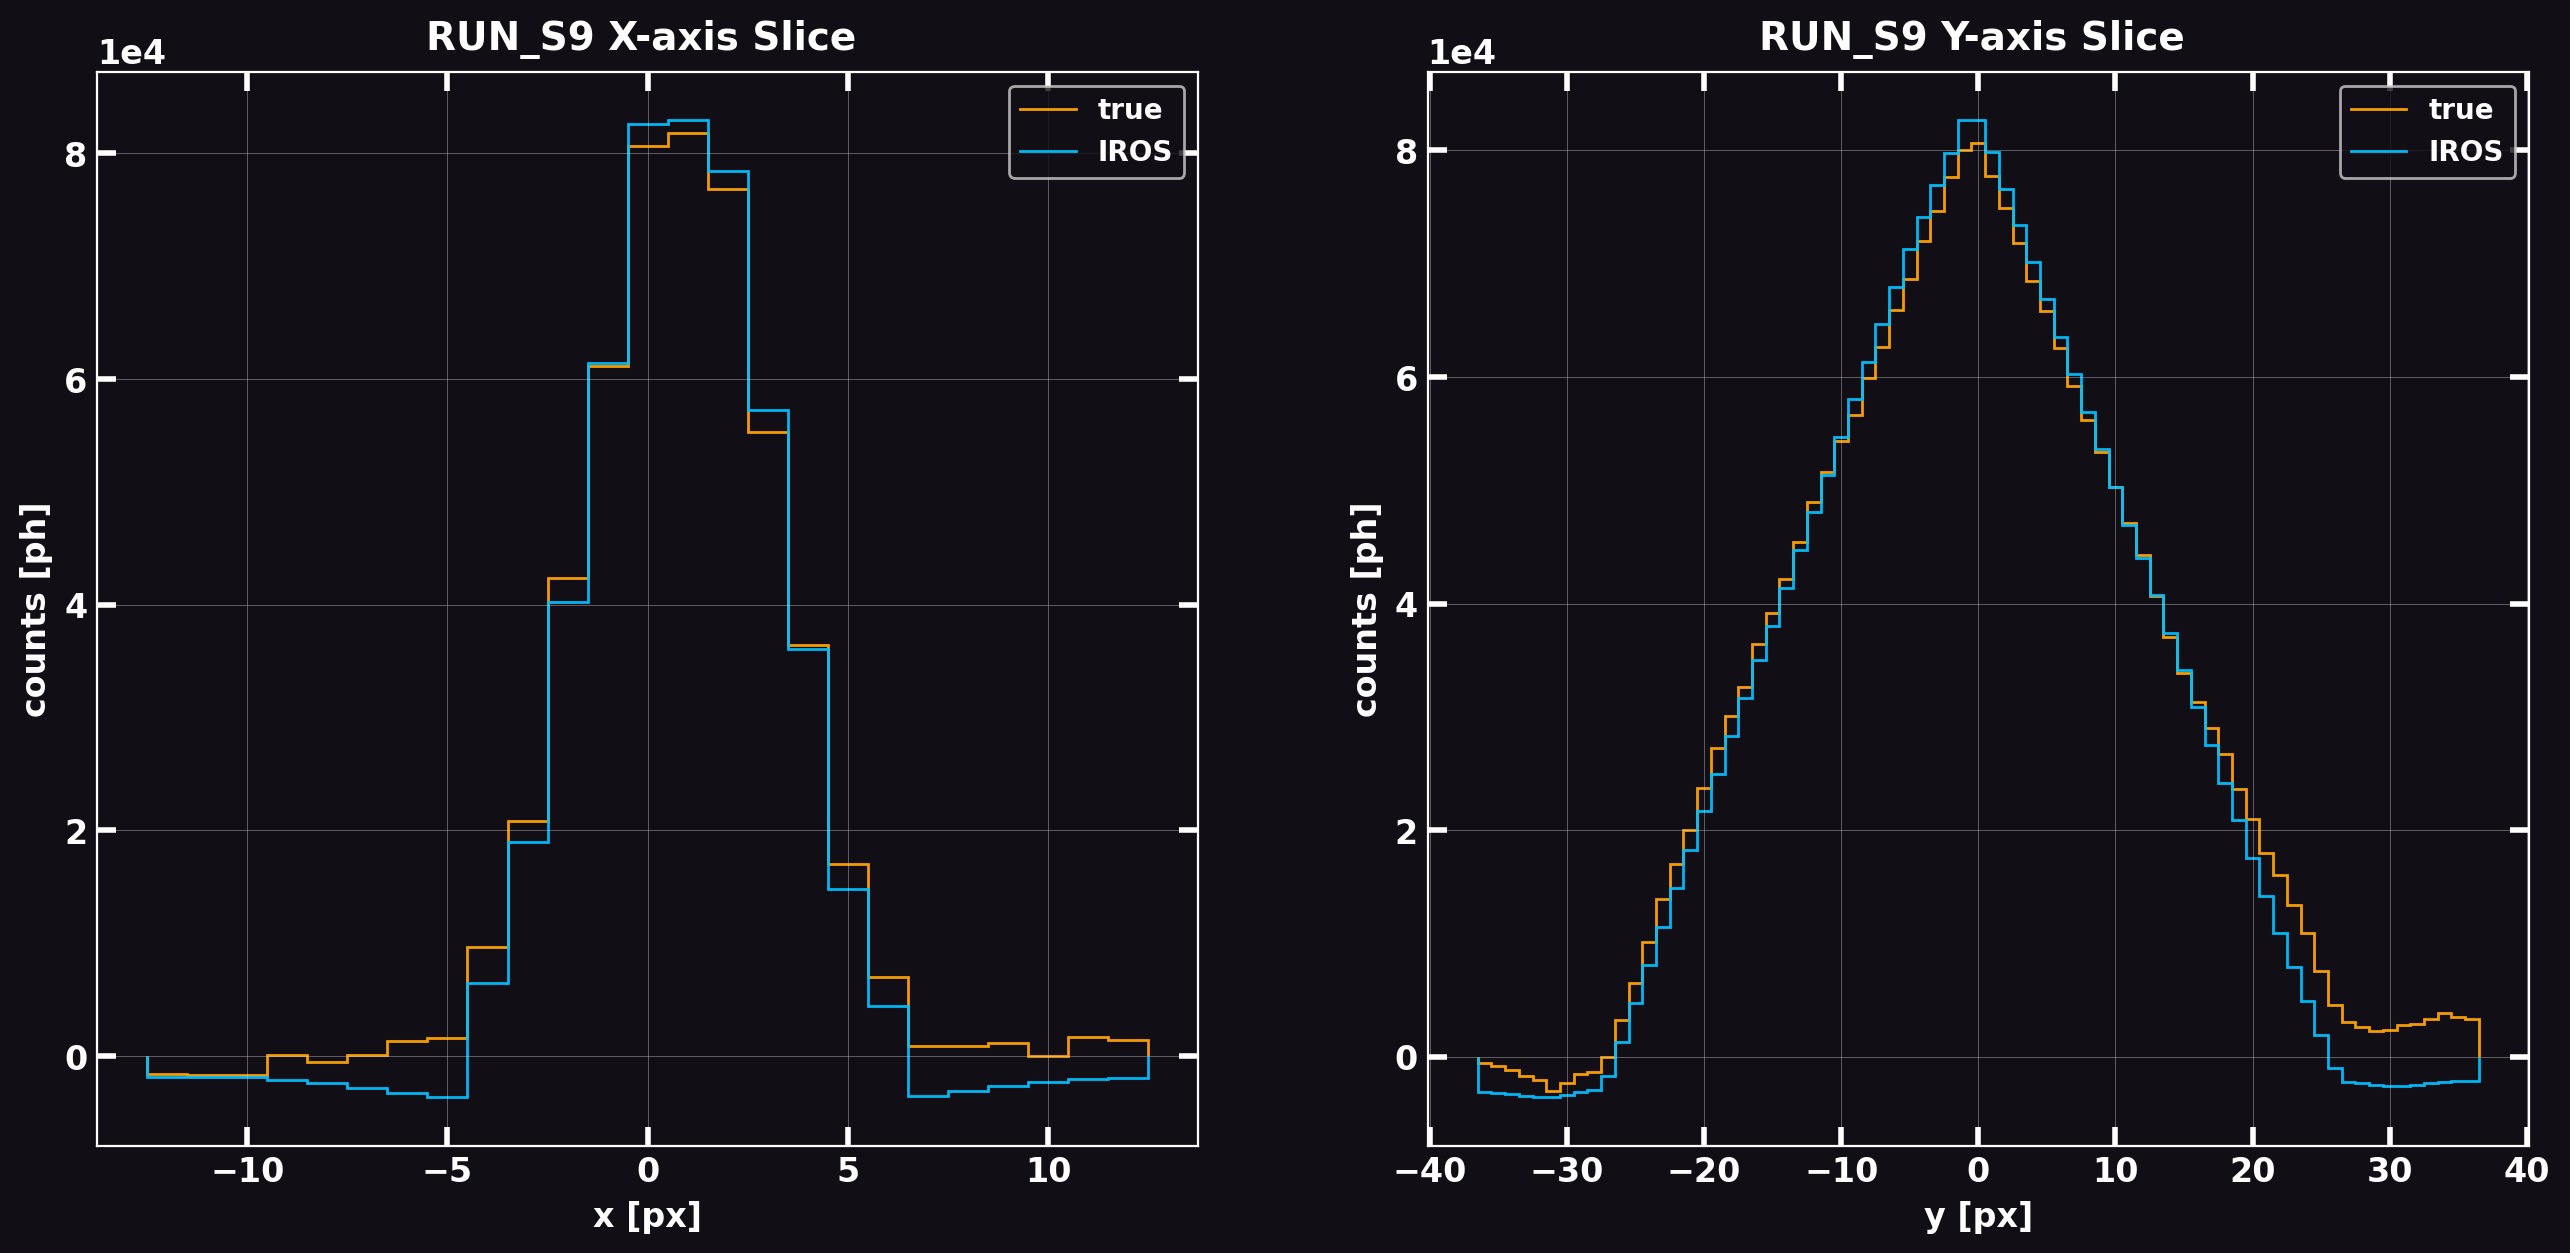

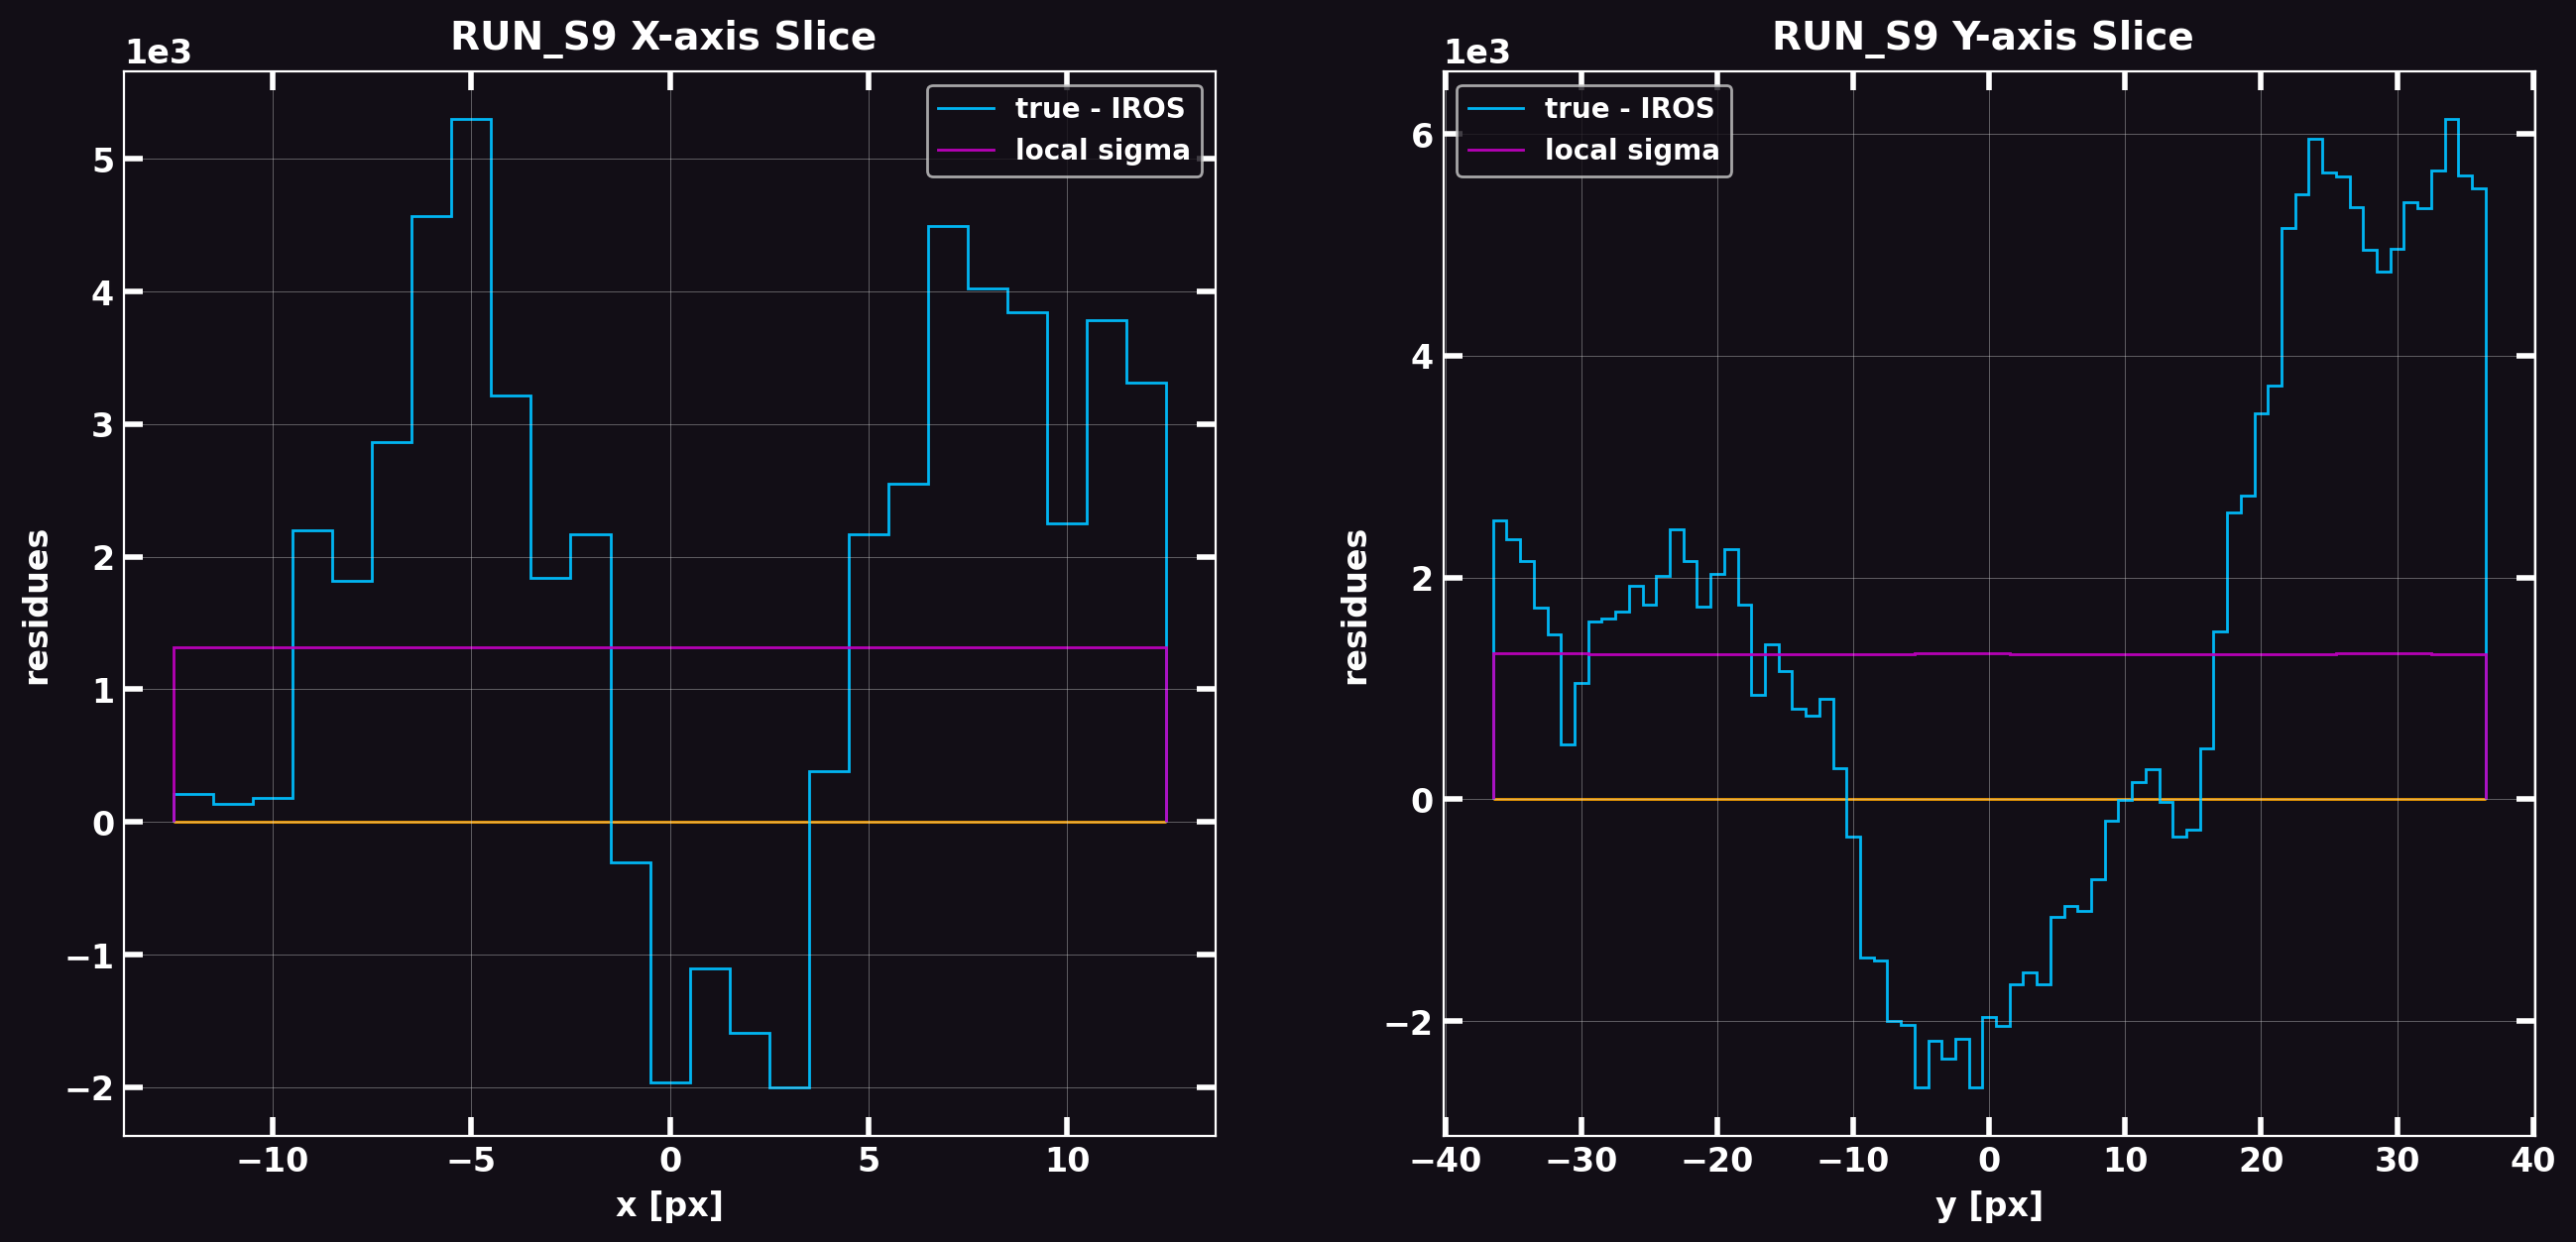

In [11]:
from bloodmoon.mask import decode
from bloodmoon.mask import variance

true_sky: NDArray = decode(wfm, detector)
varmap: NDArray = variance(wfm, detector)

plot_results(true_sky, candidates, wfm, varmap=varmap, save_to=None)

In [8]:
l = 1.75

alpha = 32.8
beta = 45.0


tan = lambda x: np.tan(np.deg2rad(x))

l * (tan(beta) - tan(alpha))

np.float64(0.6222019599013703)